# Clasificación del tipo de cubierta forestal

## Descripción

En este trabajo se comparan modelos de clasificación basados en máquinas de vectores de soporte y Random Forest sobre el dataset Covertype.

El objetivo es predecir el tipo de cubierta forestal a partir de variables cartográficas y ambientales, analizar el efecto del desbalance de clases y comparar el rendimiento de los diferentes modelos.

## Objetivos

* Explorar y preparar el conjunto de datos.
* Analizar la distribución de las clases.
* Aplicar máquinas de vectores de soporte.
* Aplicar Random Forest.
* Evaluar los modelos mediante validación cruzada y matrices de confusión.
* Estudiar técnicas de undersampling y oversampling.
* Comparar los resultados obtenidos.
* Revisar una aplicación científica de estos métodos.

### Análisis descriptivo de los datos

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns



In [ ]:
from ucimlrepo import fetch_ucirepo

covertype = fetch_ucirepo(id=31)

df = pd.DataFrame(covertype.data.features)
df['Cover_Type'] = covertype.data.targets

df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


¿Cuántas instancias de datos tiene el dataset?

In [ ]:
num_corpus = len(df)

print(f"El DataFrame contiene {num_corpus} instancias.")

df.dropna(axis=0, how='all', inplace=True)

num_corpus = len(df)

print(f"El DataFrame corregido contiene {num_corpus} instancias.")

df.shape

El DataFrame contiene 581012 instancias.
El DataFrame corregido contiene 581012 instancias.


(581012, 55)

¿Cuántas variables continuas hay en el dataset?

In [ ]:
#Voy a ver primero qué datos recoge nuestro dataframe
columnas=df.columns
print(columnas)
#Ahora vere que tipo de datos tiene cada columna
tipos_de_datos = df.dtypes
print(tipos_de_datos)


Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Soil_Type1',
       'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6',
       'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11',
       'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15',
       'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19',
       'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23',
       'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27',
       'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31',
       'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35',
       'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39',
       'Soil_Type40', 'Wilderness_Area2', 'Wilderness_Area3',
       'Wilderness_Area4

In [5]:
# Obtener valores únicos
for columna in df:
    valores_unicos = df[columna].unique()
    print(f"Valores únicos en '{columna}': {valores_unicos}")


Valores únicos en 'Elevation': [2596 2590 2804 ... 3858 3856 3852]
Valores únicos en 'Aspect': [ 51  56 139 155  45 132  49  59 201 151 134 214 157 259  72   0  38  71
 209 114  54  22 135 163 148 117 122 105 102  23  41 125  92  98 354 347
 346 330 128  68  94  99  66 100 323  79  81 315  74  11  42  75 107  90
  40  63  13  80 166   6  30 118 160 326 153 143 352  14 358 332  18 306
 173  31 164  34  84 170 211  32  57 348 333 324  88 111  53  58  76  17
 124 119 320 112  83   1  37 356 307   7  12 344 228 284 299 220   2  95
 289  21  20 200 349 328 221 257 276 196 189 130 357  15   8 288 129  28
  86 292 115  29 180 116  46 256 338 127 319  89  43 188  50 138 312   9
  10  36 167 260 187 279 245  27 359  16  48 149  60  77 230 152  70 325
 126 222 109  85  25 176 144 175 162  73  39  78 331 329 355  87 285 108
 106  24  52 261 232 246 342  61 141 216 236 254 336 278  62 237 281  69
 251 150 185 110 103 243 215 238 317 252 136 131 133 123 120 351 202 194
 101 282 258 270  65 203 353 

 variables continuas

 - Elevation
 - Aspect
 - Slope
 - Horizontal_Distance_To_Hydrology
 - Vertical_Distance_To_Hydrology
 - Horizontal_Distance_To_Roadways
 - Hillshade_9am
 - Hillshade_Noon
 - Horizontal_Distance_To_Fire_Points

 Si vemos la descripción de cada una, es lógico pensar que se van a representar como variables continuas, todas se pueden representar con una cantidad.

¿Cuántas variables categóricas hay en el dataset? Indica las categorías.

Tenemos 3 variables categóricas. Tenemos 40 diferentes tipos de suelo; y 4 diferentes tipos de ambiente. Estas dos categorías, suelo y ambiente, serían variables categóricas. 
Es por ello que tenemos 44 columnas con 1 y 0 (one hot encoding).

Además tenemos también como variable categórica, la variable objetivo: el cover type, que es el tipo de cubierta forestal que buscamos (clasificado de 1 a 7)

¿Cómo es la distribución de etiquetas de clase en el dataset? Con estos datos, ¿podríamos decir que el dataset está balanceado?

In [ ]:
df['Cover_Type'].value_counts().sort_index()


Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Podemos ver que el Dataset no está balanceado. El tipo 1 y 2 tienen muchos más datos, luego vendrían el 3, 6 y 7. Y finalmente el 5, y el 4, de este último teniendo más de 100 veces menos que el 2.

¿Existen valores nulos o perdidos en el dataset?

In [ ]:
print(df.isnull().sum())

# Revisar las columnas de ambiente
ohe_amb = df.iloc[:, [11, 52, 53, 54]]
# Revisar las columnas de suelo
ohe_soil = df.iloc[:, 12:52]

# Comprobar si alguna columna tiene solo ceros
amb_all_zeros = (ohe_amb == 0).sum()
soil_all_zeros = (ohe_soil == 0).sum()

# Imprimir el resultado
print("Columnas de la primera variable One-Hot Encoding con solo ceros:")
print(amb_all_zeros[amb_all_zeros == len(df)])

print("\nColumnas de la segunda variable One-Hot Encoding con solo ceros:")
print(soil_all_zeros[soil_all_zeros == len(df)])




Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0
Soil_Type12                           0
Soil_Type13                           0
Soil_Type14                           0


Vemos que no hay valores nulos o perdidos.

¿Existe alguna variable altamente correlacionada con la variable de clase?

In [7]:
#Hacemos una correlación rápida solo para ver todas las variables, que no nos da información de las dos categóricas. Vemos que las demás no nos aportan nada. En el siguiente recuadro estudiaremos para estas dos variables.
df.corr()['Cover_Type'].sort_values(ascending=False)



Cover_Type                            1.000000
Wilderness_Area4                      0.323200
Soil_Type10                           0.243876
Soil_Type38                           0.160170
Soil_Type39                           0.155668
Slope                                 0.148285
Soil_Type40                           0.128351
Soil_Type2                            0.118135
Soil_Type6                            0.112958
Soil_Type4                            0.099672
Soil_Type1                            0.090828
Soil_Type17                           0.090582
Vertical_Distance_To_Hydrology        0.081664
Soil_Type35                           0.080315
Soil_Type37                           0.080271
Soil_Type5                            0.077890
Soil_Type3                            0.068064
Wilderness_Area3                      0.066846
Soil_Type14                           0.065562
Soil_Type11                           0.035379
Soil_Type36                           0.025397
Soil_Type13  

In [10]:

# Calcular la correlación de la variable de clase con las columnas de One-Hot Encoding
correlation_with_target_ohe_amb = ohe_amb.corrwith(df['Cover_Type'])
correlation_with_target_ohe_soil = ohe_soil.corrwith(df['Cover_Type'])
print(correlation_with_target_ohe_amb)
print(correlation_with_target_ohe_soil)


Soil_Type1          0.090828
Wilderness_Area3    0.066846
Wilderness_Area4    0.323200
Cover_Type          1.000000
dtype: float64
Soil_Type2          0.118135
Soil_Type3          0.068064
Soil_Type4          0.099672
Soil_Type5          0.077890
Soil_Type6          0.112958
Soil_Type7         -0.000496
Soil_Type8         -0.003667
Soil_Type9         -0.006110
Soil_Type10         0.243876
Soil_Type11         0.035379
Soil_Type12        -0.023601
Soil_Type13         0.024404
Soil_Type14         0.065562
Soil_Type15         0.006425
Soil_Type16         0.009844
Soil_Type17         0.090582
Soil_Type18         0.007390
Soil_Type19        -0.036452
Soil_Type20        -0.028665
Soil_Type21        -0.025400
Soil_Type22        -0.141746
Soil_Type23        -0.135055
Soil_Type24        -0.068746
Soil_Type25        -0.006449
Soil_Type26        -0.000375
Soil_Type27        -0.014407
Soil_Type28        -0.001702
Soil_Type29        -0.124933
Soil_Type30        -0.010436
Soil_Type31        -0.065347

Vemos que ninguna de las variables tiene correlación con la variable objetivo.

¿Qué tres variables del dataset consideras que pueden influenciar más en la clasificación de los datos?¿Qué pruebas harías para comprobar tus hipótesis? Hazlas.

Analizando el Dataset, parece lógico pensar que las dos variables que más influenciarán a la clasificación de los datos es en primer lugar el área silvestre en el que nos encontramos, y en segundo lugar el tipo de suelo.
Además, de entre las demás variables, diría que la altitud es la que más información nos puede aportar, nos puede ayudar principalmente a saber en que área silvestre nos encontramos, luego indirectamente también influirá en el tipo de cubierta forestal.

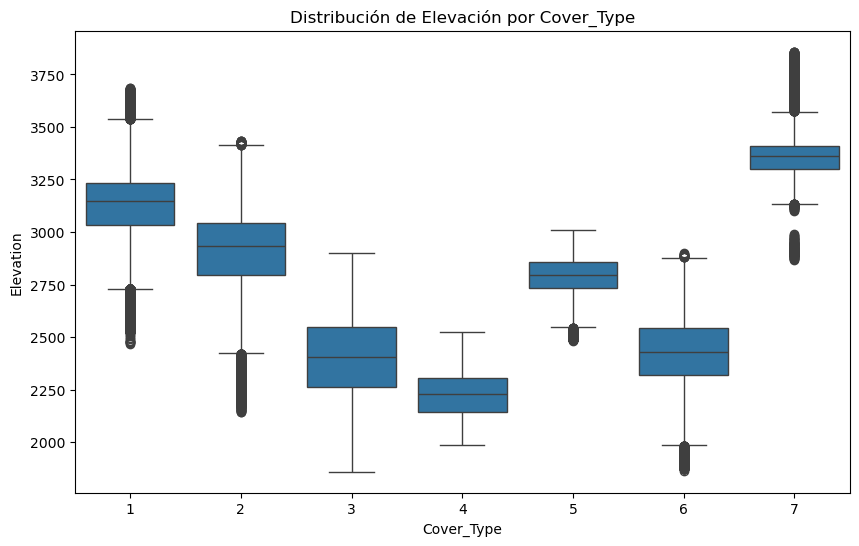

"\n# Separamos los datos en los conjuntos de entrenamiento y test.\nfrom sklearn.model_selection import train_test_split\n\nX, y = df.drop('Cover_Type',axis=1),df['Cover_Type']\n\nX_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.8, random_state=1)"

In [11]:
import seaborn as sns

#Vamos a ver primero la posible correlación con la altitud
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cover_Type', y='Elevation', data=df)
plt.title("Distribución de Elevación por Cover_Type")
plt.xlabel("Cover_Type")
plt.ylabel("Elevation")
plt.show()
#Vemos que sí tenemos diferentes altitudes para las diferentes cubiertas. Es verdad que tenemos muchos valores fuera del diagrama de cajas, lo que quizás sea el motivo de la baja correlación, pero si parece ser una variable importante que nos va a dar mucha información

"""
# Separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = df.drop('Cover_Type',axis=1),df['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.8, random_state=1)"""

In [12]:
# Tablas de frecuencia para Wilderness_Area
for wilderness in [col for col in df.columns if "Wilderness_Area" in col]:
    print(f"Distribución para {wilderness}:")
    print(pd.crosstab(df['Cover_Type'], df[wilderness]))
    print("\n")

#Con esto vemos que van a aportarnos información. Según el área silvestre en el que nos encontramos vemos diferentes tipos de cubiertas.

Distribución para Wilderness_Area1:
Wilderness_Area1       0       1
Cover_Type                      
1                 106123  105717
2                 137104  146197
3                  35754       0
4                   2747       0
5                   5712    3781
6                  17367       0
7                  15409    5101


Distribución para Wilderness_Area2:
Wilderness_Area2       0      1
Cover_Type                     
1                 193245  18595
2                 274316   8985
3                  35754      0
4                   2747      0
5                   9493      0
6                  17367      0
7                  18206   2304


Distribución para Wilderness_Area3:
Wilderness_Area3       0       1
Cover_Type                      
1                 124312   87528
2                 158208  125093
3                  21454   14300
4                   2747       0
5                   3781    5712
6                   9741    7626
7                   7405   13105


Dist

In [13]:
# Tablas de frecuencia para Soil_Type
for soil in [col for col in df.columns if "Soil_Type" in col]:
    print(f"Distribución para {soil}:")
    print(pd.crosstab(df['Cover_Type'], df[soil]))
    print("\n")

#Vemos que ocurre lo mismo con los suelos. Aunque esto sería suficiente, esto se vería también en unos histogramas, que dibujaremos a continuación.

Distribución para Soil_Type1:
Soil_Type1       0     1
Cover_Type              
1           211840     0
2           283301     0
3            33653  2101
4             2569   178
5             9493     0
6            16615   752
7            20510     0


Distribución para Soil_Type2:
Soil_Type2       0     1
Cover_Type              
1           211840     0
2           282449   852
3            30763  4991
4             2632   115
5             9229   264
6            16064  1303
7            20510     0


Distribución para Soil_Type3:
Soil_Type3       0     1
Cover_Type              
1           211840     0
2           282110  1191
3            33343  2411
4             1729  1018
5             9493     0
6            17164   203
7            20510     0


Distribución para Soil_Type4:
Soil_Type4       0     1
Cover_Type              
1           211658   182
2           280050  3251
3            28253  7501
4             2579   168
5             8908   585
6            16736   631

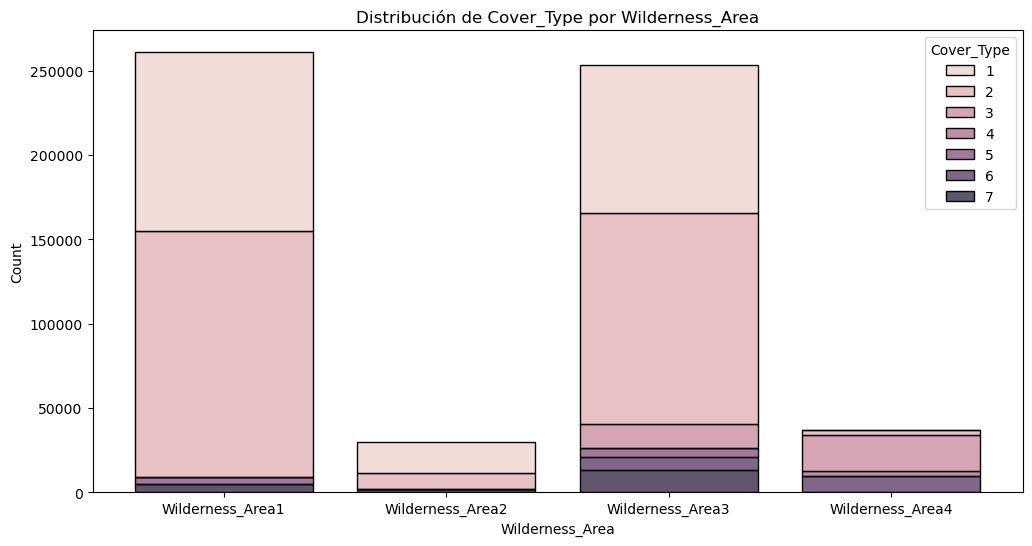

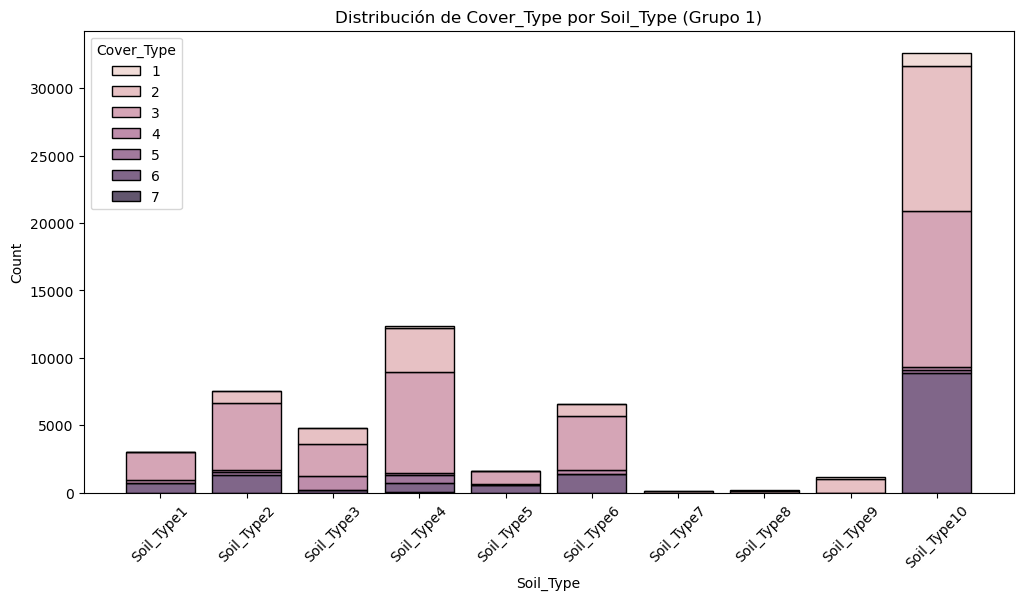

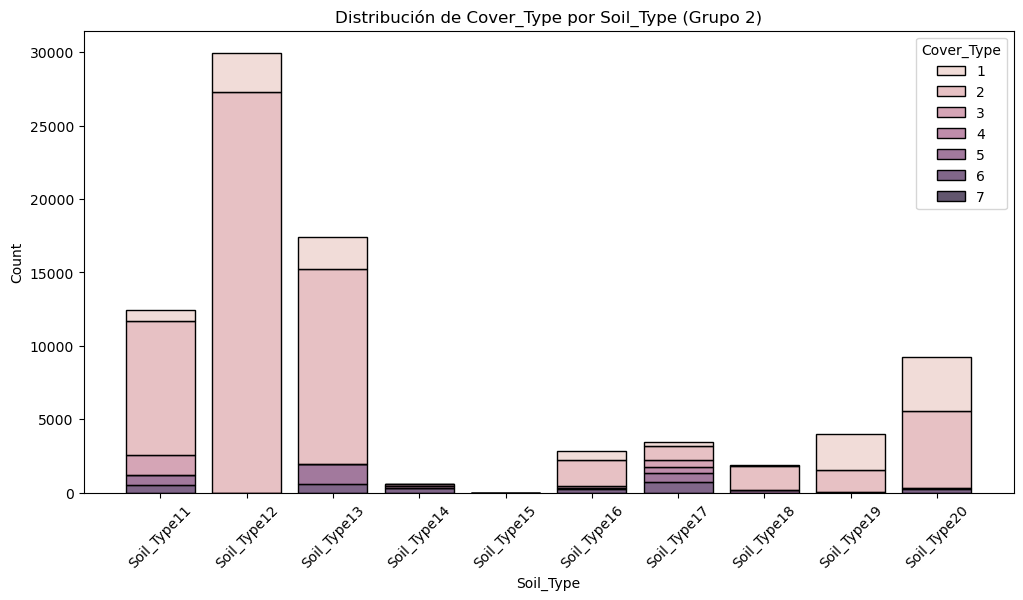

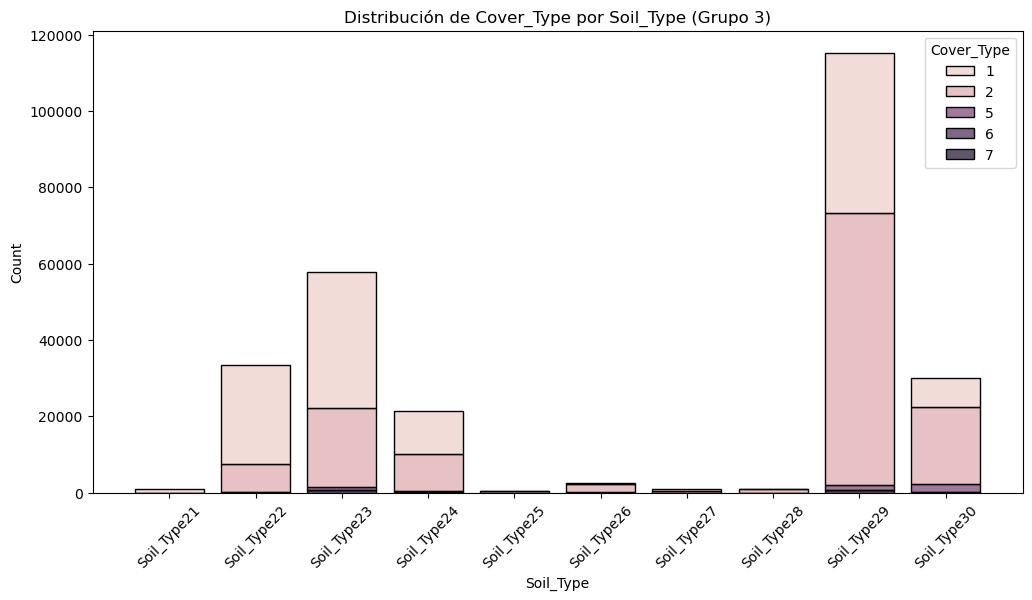

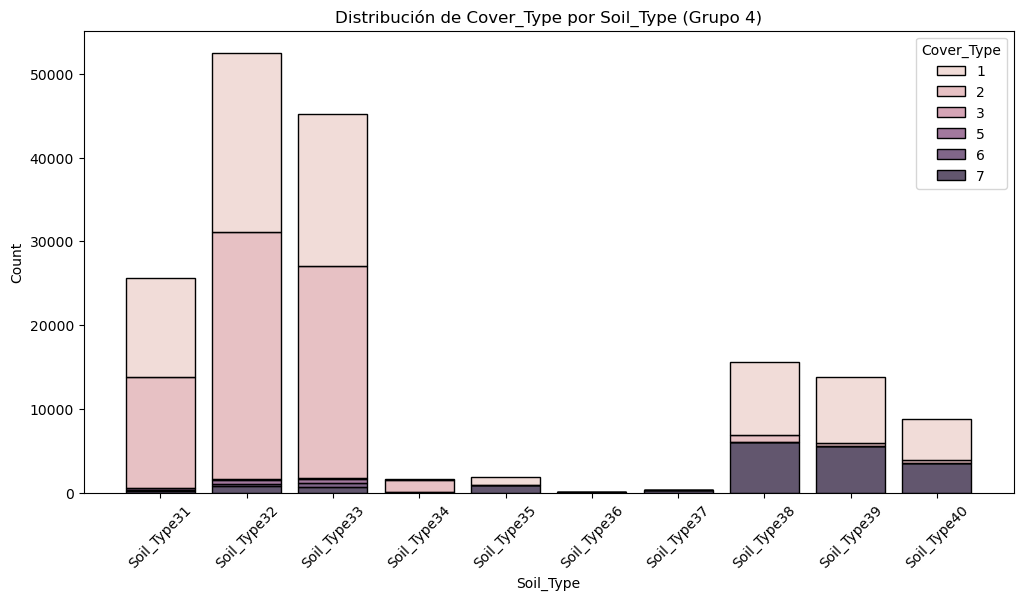

In [14]:
# Wilderness_Area
wilderness_cols = [col for col in df.columns if "Wilderness_Area" in col]
wilderness_data = df[wilderness_cols + ['Cover_Type']].melt(id_vars='Cover_Type', 
                                                                 var_name='Wilderness_Area', 
                                                                 value_name='Presence')

plt.figure(figsize=(12, 6))
sns.histplot(data=wilderness_data[wilderness_data['Presence'] == 1], 
             x='Wilderness_Area', hue='Cover_Type', multiple='stack', shrink=0.8)
plt.title('Distribución de Cover_Type por Wilderness_Area')
plt.show()

# Soil_Type
# Obtener las columnas de Soil_Type
soil_cols = [col for col in df.columns if "Soil_Type" in col]

# Dividir en cuatro grupos
soil_groups = [soil_cols[i:i+10] for i in range(0, len(soil_cols), 10)]

# Crear histogramas por grupos
for i, group in enumerate(soil_groups):
    soil_data_group = df[group + ['Cover_Type']].melt(id_vars='Cover_Type', 
                                                           var_name='Soil_Type', 
                                                           value_name='Presence')

    plt.figure(figsize=(12, 6))
    sns.histplot(data=soil_data_group[soil_data_group['Presence'] == 1], 
                 x='Soil_Type', hue='Cover_Type', multiple='stack', shrink=0.8)
    plt.title(f'Distribución de Cover_Type por Soil_Type (Grupo {i+1})')
    plt.xticks(rotation=45)
    plt.show()


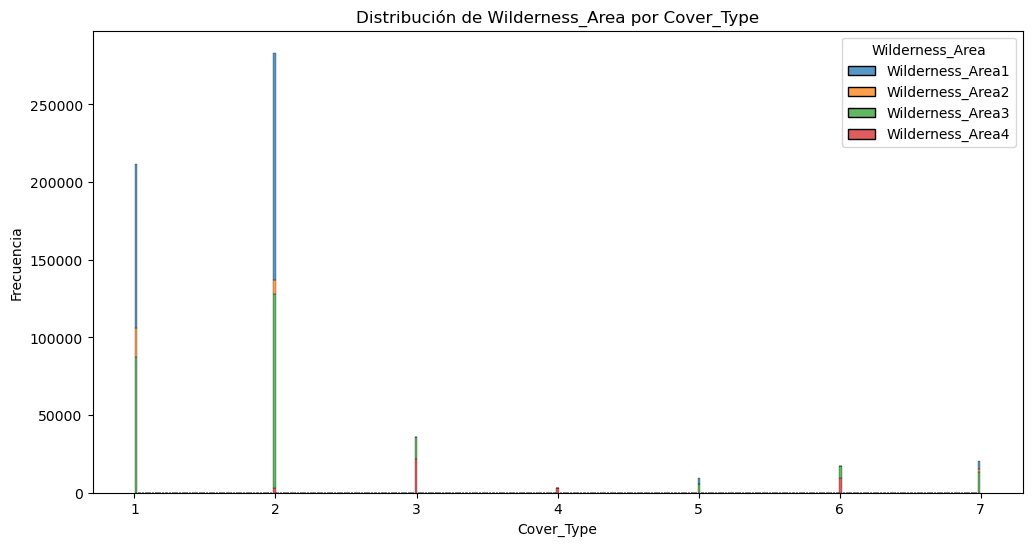

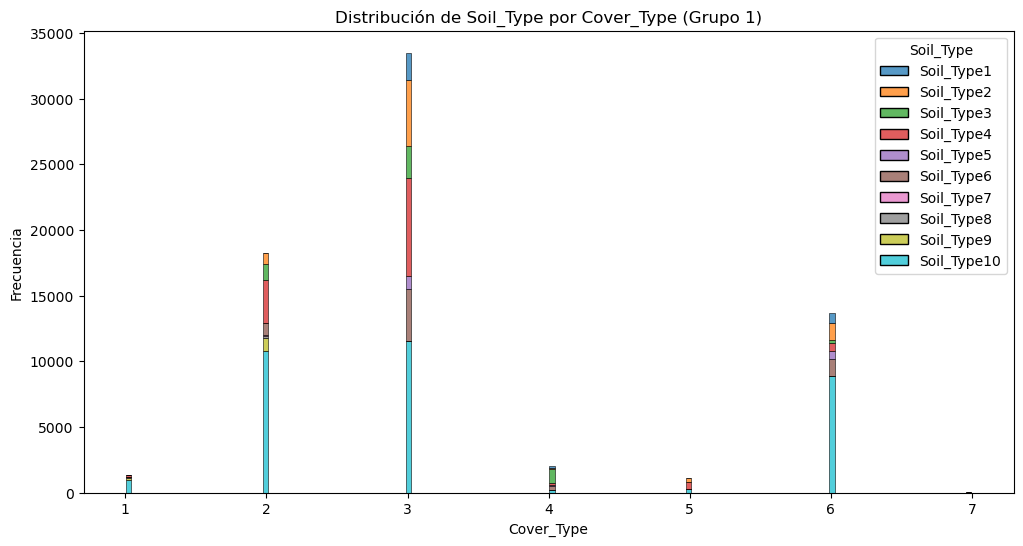

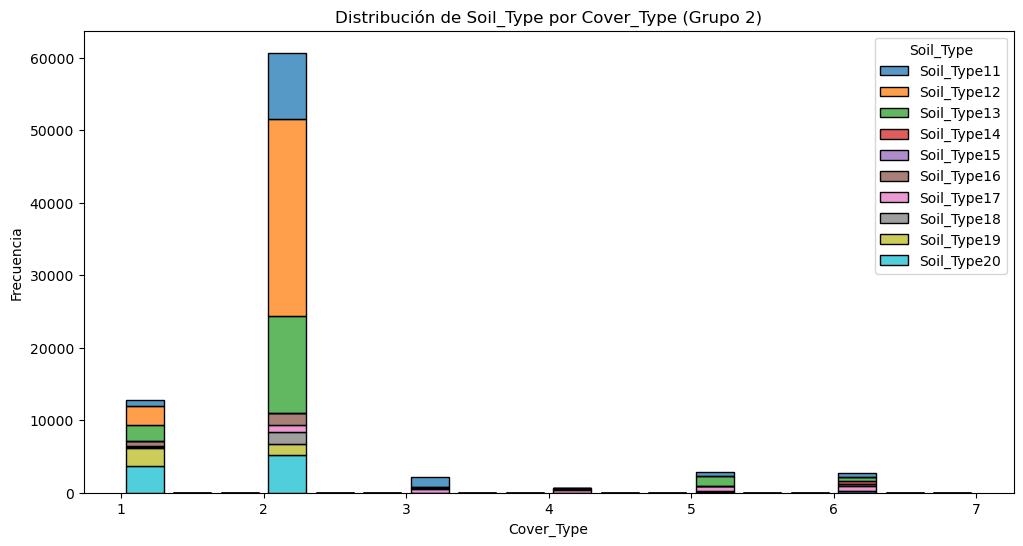

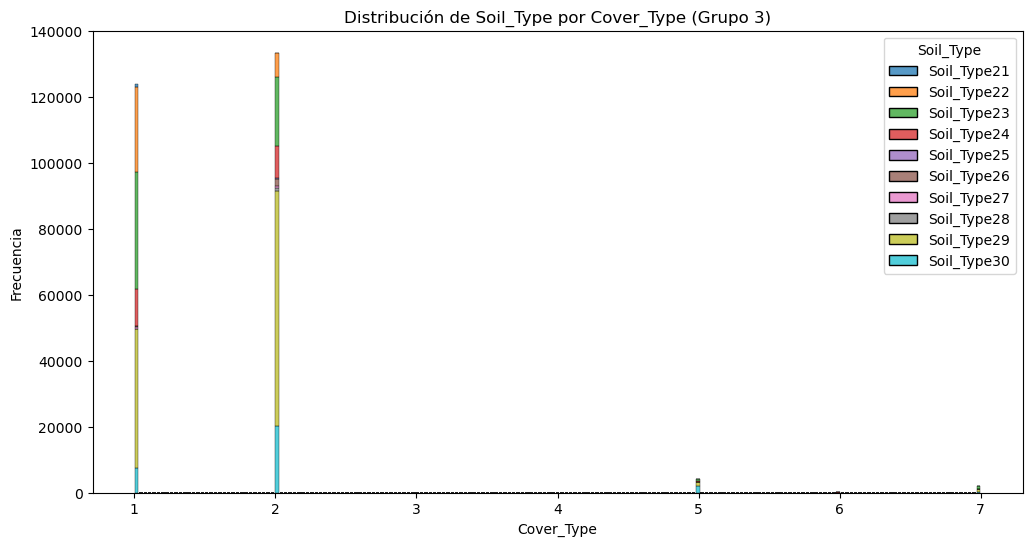

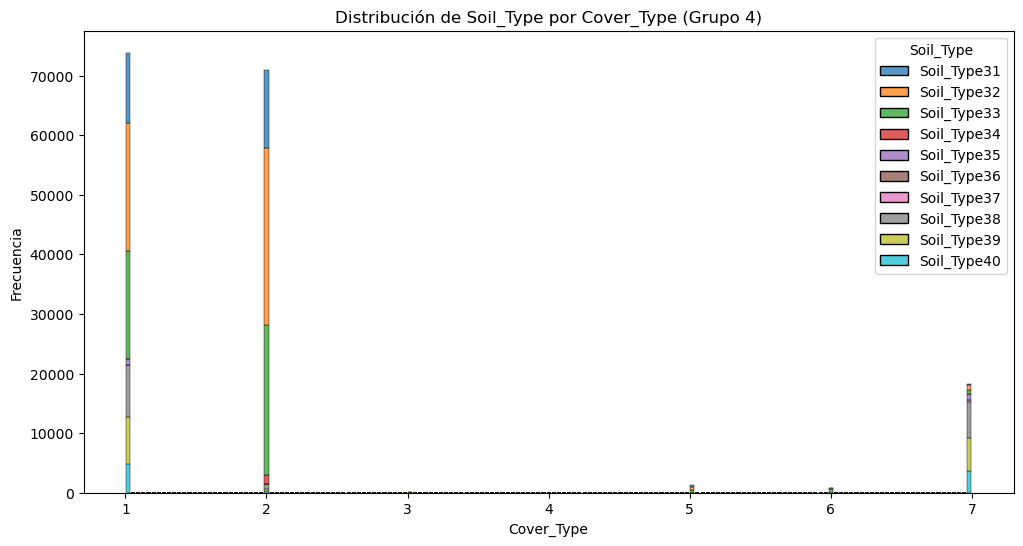

In [15]:
"""
Puede ser interesante ver estos datos al revés, es decir, para las diferentes cubiertas, con qué nos encontramos.
Otro ejercicio interesante sería verlo porcentualmente, especialmente porque la muestra que tenemos no está balanceada, y pueden engañar los resultados.
Igualmente, para ver si nos pueden aportar información, con esto es suficiente. Podemos proceder a hacer el Random Forest, donde tendremos que balancear los datos.
Si que voy a sacar los resultados que hemos comentado para ver que nos encontramos en las diferentes cubiertas. Nos da más idea con numeros gordos. 
"""
# Wilderness_Area por Cover_Type
wilderness_cols = [col for col in df.columns if "Wilderness_Area" in col]
wilderness_data = df[wilderness_cols + ['Cover_Type']].melt(id_vars='Cover_Type', 
                                                                 var_name='Wilderness_Area', 
                                                                 value_name='Presence')

plt.figure(figsize=(12, 6))
sns.histplot(data=wilderness_data[wilderness_data['Presence'] == 1], 
             x='Cover_Type', hue='Wilderness_Area', multiple='stack', shrink=0.8)
plt.title('Distribución de Wilderness_Area por Cover_Type')
plt.xlabel('Cover_Type')
plt.ylabel('Frecuencia')
plt.show()

# Soil_Type por Cover_Type (Dividido en grupos)
soil_cols = [col for col in df.columns if "Soil_Type" in col]
soil_groups = [soil_cols[i:i+10] for i in range(0, len(soil_cols), 10)]

for i, group in enumerate(soil_groups):
    soil_data_group = df[group + ['Cover_Type']].melt(id_vars='Cover_Type', 
                                                           var_name='Soil_Type', 
                                                           value_name='Presence')

    plt.figure(figsize=(12, 6))
    sns.histplot(data=soil_data_group[soil_data_group['Presence'] == 1], 
                 x='Cover_Type', hue='Soil_Type', multiple='stack', shrink=0.8)
    plt.title(f'Distribución de Soil_Type por Cover_Type (Grupo {i+1})')
    plt.xlabel('Cover_Type')
    plt.ylabel('Frecuencia')
    plt.show()
    
#A groso modo vemos que algunas cubiertas solo se dan en algunas áreas silvestres y para un tipo de suelo.
    



### Clasificación

**Random Forest**

En esta parte de la actividad hay que utilizar la librería https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html para resolver el problema de clasificación.

El algortimo de RF necesitar ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- n_estimators
- criterion
- max_depth
- min_samples_split
- min_samples_leaf
- max_features

Indica qué son cada uno de estos hiperparámetros

- n_estimators

Es el número de árboles en el bosque del modelo de Random Forest.

Un mayor número de árboles generalmente mejora la estabilidad y precisión del modelo, pero también aumenta el tiempo de entrenamiento y predicción.
Si es muy bajo, el modelo puede no capturar suficiente información del conjunto de datos.

- criterion

La función que mide la calidad de una división en cada nodo del árbol.

Opciones comunes: "gini" mide la pureza de los nodos, "entropy" usa la entropía de la información para medir la impureza de los nodos.

El criterio afecta a cómo se seleccionan las divisiones en el árbol, y por ende, las decisiones finales del modelo.

- max_depth

La profundidad máxima de los árboles en el bosque.

Controla la complejidad del modelo. Si es demasiado alta, el modelo puede sobreajustarse al dataset (overfitting).
Si es demasiado baja, el modelo puede no capturar suficiente la información (underfitting)

- min_samples_split

El número mínimo de muestras requeridas para dividir un nodo.

Un valor bajo permite que los árboles crezcan más profundamente, lo que puede llevar al sobreajuste.
Un valor alto genera árboles más generales, lo que reduce el riesgo de sobreajuste, pero puede incrementar el error de sesgo.

- min_samples_leaf

El número mínimo de muestras necesarias para ser una hoja del árbol.

Evita que las hojas tengan un número muy bajo de muestras, lo que puede reducir el sobreajuste.
Un valor más alto fuerza a las hojas a ser más grandes, lo que simplifica el modelo.

- max_features

El número máximo de características a considerar al dividir un nodo.

Limitar el número de características usadas en cada división reduce la correlación entre los árboles, mejorando la generalización.
Un valor demasiado bajo puede hacer que el modelo no captura información importante.

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro _class_weight_

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

El parámetro class_weight asigna un peso relativo a cada clase en el conjunto de datos. Este peso influye en la función de pérdida que utiliza el algoritmo para entrenar el modelo, penalizando más los errores en las clases con mayor peso.

Puede ser útil para mejorar métricas como recall y F1-score y para reducir el sesgo del modelo, pero es una herramienta especialmente poderosa para abordar problemas de desbalanceo de clases, evitando la necesidad de modificar los datos.
Por tanto, va a ser muy útil en nuestro caso.

Como primer paso para crear un clasificador de Random Forest hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos.
¿Hace falta normalizar los datos?

En Random Forest no hace falta normalizar datos.

Esto es porque Random Forest toma las decisiones en base a cada característica en diferentes nodos, luego no depende de la escala en las que estén esas variables.
Es decir, busca umbrales óptimos para dividir los datos, y por tanto es irrelevante la escala.

Podría ayudar un preprocesamiento previo para eliminar variables redundantes o manejar valores faltantes (lo cual puede mejorar el funcionamiento del modelo pero no es estrictamente necesario).
En nuestro caso hemos visto que no hay valores faltantes. Además, las variables categóricas están bien representadas.

El único problema que tiene el dataset es el desbalanceo en las clases. Pero esto se corregiría con class_weight.
No se hará ningún preprocesamiento.

Entrena un conjunto de modelos de Random Forest que utilicen todas las variables del dataset, con 5, 10, 20, 50 y 100 árboles. El criterio para realizar las particiones debe ser Gini-index, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

_Nota: el entrenamiento puede tardar entre 3 y 15 minutos en función de las características del equipo._

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [17]:
# numero de árboles: 5, 10, 20, 50 y 100

n_arboles = {5,10,20,50,100}
particion = 'gini'
max_depth = 10
min_samples_split = 10
min_samples_leaf = 2
max_feature = None


randomForest_5 = RandomForestClassifier(n_estimators = 5, criterion= particion,
                                       max_depth = max_depth, min_samples_split = min_samples_split,
                                      min_samples_leaf = min_samples_leaf, max_features =None) 

randomForest_10 = RandomForestClassifier(n_estimators = 10, criterion= particion,
                                       max_depth = max_depth, min_samples_split = min_samples_split,
                                      min_samples_leaf = min_samples_leaf, max_features =None) 

randomForest_20 = RandomForestClassifier(n_estimators = 20, criterion= particion,
                                       max_depth = max_depth, min_samples_split = min_samples_split,
                                      min_samples_leaf = min_samples_leaf, max_features =None) 

randomForest_50 = RandomForestClassifier(n_estimators = 50, criterion= particion,
                                       max_depth = max_depth, min_samples_split = min_samples_split,
                                      min_samples_leaf = min_samples_leaf, max_features =None) 

randomForest_100 = RandomForestClassifier(n_estimators = 100, criterion= particion,
                                       max_depth = max_depth, min_samples_split = min_samples_split,
                                      min_samples_leaf = min_samples_leaf, max_features =None) 


In [ ]:
# Separamos los datos en los conjuntos de entrenamiento y test.
X, y = df.drop('Cover_Type',axis=1),df['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=1)


In [19]:
#5 árboles
# Entrenamiento
randomForest_5.fit(X_train, y_train)
    
# Predicción en el conjunto de prueba
y_pred_train_5 = randomForest_5.predict(X_train)
    
# Evaluación
accuracy_5 = accuracy_score(y_train, y_pred_train_5)
print(f"Accuracy con 5 árboles: {accuracy_5:.4f}")
print(classification_report(y_train, y_pred_train_5))



Accuracy con 5 árboles: 0.7958
              precision    recall  f1-score   support

           1       0.79      0.77      0.78    169565
           2       0.80      0.86      0.83    226699
           3       0.78      0.87      0.82     28485
           4       0.88      0.69      0.78      2201
           5       0.86      0.24      0.37      7564
           6       0.77      0.36      0.49     13871
           7       0.91      0.75      0.82     16424

    accuracy                           0.80    464809
   macro avg       0.82      0.65      0.70    464809
weighted avg       0.80      0.80      0.79    464809



In [20]:
#10 árboles
# Entrenamiento
randomForest_10.fit(X_train, y_train)
    
# Predicción en el conjunto de prueba
y_pred_train_10 = randomForest_10.predict(X_train)
    
# Evaluación
accuracy_10 = accuracy_score(y_train, y_pred_train_10)
print(f"Accuracy con 10 árboles: {accuracy_10:.4f}")
print(classification_report(y_train, y_pred_train_10))

Accuracy con 10 árboles: 0.7963
              precision    recall  f1-score   support

           1       0.79      0.77      0.78    169565
           2       0.80      0.86      0.83    226699
           3       0.79      0.86      0.82     28485
           4       0.87      0.71      0.78      2201
           5       0.87      0.24      0.38      7564
           6       0.75      0.39      0.51     13871
           7       0.91      0.74      0.81     16424

    accuracy                           0.80    464809
   macro avg       0.82      0.65      0.70    464809
weighted avg       0.80      0.80      0.79    464809



In [21]:
#20 árboles
# Entrenamiento
randomForest_20.fit(X_train, y_train)
    
# Predicción en el conjunto de prueba
y_pred_train_20 = randomForest_20.predict(X_train)
    
# Evaluación
accuracy_20 = accuracy_score(y_train, y_pred_train_20)
print(f"Accuracy con 20 árboles: {accuracy_20:.4f}")
print(classification_report(y_train, y_pred_train_20))

Accuracy con 20 árboles: 0.7962
              precision    recall  f1-score   support

           1       0.79      0.77      0.78    169565
           2       0.80      0.86      0.83    226699
           3       0.78      0.87      0.82     28485
           4       0.87      0.70      0.78      2201
           5       0.84      0.25      0.38      7564
           6       0.78      0.36      0.49     13871
           7       0.91      0.73      0.81     16424

    accuracy                           0.80    464809
   macro avg       0.82      0.65      0.70    464809
weighted avg       0.80      0.80      0.79    464809



In [22]:
#50 árboles
# Entrenamiento
randomForest_50.fit(X_train, y_train)
    
# Predicción en el conjunto de prueba
y_pred_train_50 = randomForest_50.predict(X_train)
    
# Evaluación
accuracy_50 = accuracy_score(y_train, y_pred_train_50)
print(f"Accuracy con 50 árboles: {accuracy_50:.4f}")
print(classification_report(y_train, y_pred_train_50))

Accuracy con 50 árboles: 0.7978
              precision    recall  f1-score   support

           1       0.79      0.77      0.78    169565
           2       0.80      0.86      0.83    226699
           3       0.78      0.87      0.82     28485
           4       0.88      0.70      0.78      2201
           5       0.83      0.25      0.38      7564
           6       0.78      0.36      0.49     13871
           7       0.91      0.74      0.82     16424

    accuracy                           0.80    464809
   macro avg       0.82      0.65      0.70    464809
weighted avg       0.80      0.80      0.79    464809



In [23]:
#100 árboles
# Entrenamiento
randomForest_100.fit(X_train, y_train)
    
# Predicción en el conjunto de prueba
y_pred_train_100 = randomForest_100.predict(X_train)
    
# Evaluación
accuracy_100 = accuracy_score(y_train, y_pred_train_100)
print(f"Accuracy con 100 árboles: {accuracy_100:.4f}")
print(classification_report(y_train, y_pred_train_100))

Accuracy con 100 árboles: 0.7982
              precision    recall  f1-score   support

           1       0.79      0.77      0.78    169565
           2       0.80      0.86      0.83    226699
           3       0.78      0.87      0.82     28485
           4       0.87      0.70      0.78      2201
           5       0.87      0.24      0.38      7564
           6       0.76      0.36      0.49     13871
           7       0.91      0.74      0.82     16424

    accuracy                           0.80    464809
   macro avg       0.83      0.65      0.70    464809
weighted avg       0.80      0.80      0.79    464809



Vemos que apenas mejoramos el modelo aumentando el número de árboles y sin embargo el coste computacional es cada vez mayor (es relativamente proporcional, puesto que va analizando una proporción diferente de árboles). Lo mejor sería quedarnos con el modelo de los 5 árboles. Voy a comprobar los resultados para un árbol, y ver si ahi sí merece la pena hacer 5. Esto probablemente se vea alterado si el número máximo de características no fuesen todas, puesto que los árboles serían más heterogéneos.

In [24]:
randomForest_1 = RandomForestClassifier(n_estimators = 1, criterion= particion,
                                       max_depth = max_depth, min_samples_split = min_samples_split,
                                      min_samples_leaf = min_samples_leaf, max_features =None) 

#1 árboles
# Entrenamiento
randomForest_1.fit(X_train, y_train)
    
# Predicción en el conjunto de prueba
y_pred_train_1 = randomForest_1.predict(X_train)
    
# Evaluación
accuracy_1 = accuracy_score(y_train, y_pred_train_1)
print(f"Accuracy con 1 árboles: {accuracy_1:.4f}")
print(classification_report(y_train, y_pred_train_1))

#Vemos que ya para un árbol tenemos bastante buena precisión

Accuracy con 1 árboles: 0.7806
              precision    recall  f1-score   support

           1       0.78      0.74      0.76    169565
           2       0.78      0.86      0.82    226699
           3       0.74      0.84      0.79     28485
           4       0.80      0.68      0.74      2201
           5       0.75      0.24      0.36      7564
           6       0.71      0.25      0.37     13871
           7       0.87      0.73      0.80     16424

    accuracy                           0.78    464809
   macro avg       0.77      0.62      0.66    464809
weighted avg       0.78      0.78      0.77    464809



Visualiza la matriz de confusión del modelo entrenado con 20 árboles.

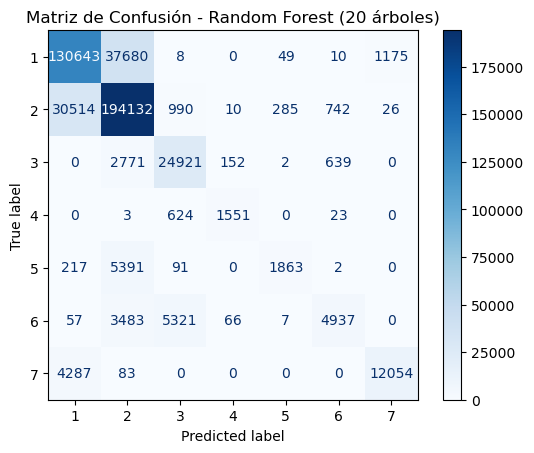

In [ ]:
# Matriz de confusión
conf_matrix_20 = confusion_matrix(y_train, y_pred_train_20)

# Visualización
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_20, display_labels=randomForest_20.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matriz de Confusión - Random Forest (20 árboles)")
plt.show()



¿Cuántos ejemplos ha clasificado correctamente?


In [26]:
# Sumar la diagonal principal (predicciones correctas)
correct_predictions = conf_matrix_20.diagonal().sum()

# Mostrar el total de ejemplos y los correctos
total_predictions = conf_matrix_20.sum()
incorrect_predictions=total_predictions-correct_predictions
print(f"Total de ejemplos: {total_predictions}")
print(f"Ejemplos correctamente clasificados: {correct_predictions}")
print(f"Ejemplos incorrectamente clasificados: {incorrect_predictions}")
print(f"Precisión general: {correct_predictions / total_predictions:.4f}")

Total de ejemplos: 464809
Ejemplos correctamente clasificados: 370101
Ejemplos incorrectamente clasificados: 94708
Precisión general: 0.7962


Explica cómo funciona la clasificación para cada una de las 7 clases. ¿Hay alguna clase que clasifica mejor que otras?

In [27]:
# Como hemos visto anteriormente 
# Generar un reporte de clasificación con precisión, recall y F1-score para cada clase
report = classification_report(y_train, y_pred_train_20, target_names=['1', '2', '3', '4', '5', '6', '7'])

print("Reporte de clasificación:")
print(report)

"""
Vemos que sí funciona mejor para unas clases que para otras. En general la precisión es alta en todas.

Pero sorprende ver como el recall es bajo para el 6, pero especialmente para el 5, esto implica que tenemos muchos falsos negativos para estas dos variables.

Si echamos un ojo a la matriz de confusión, vemos que hay muchas instancias (muchísimas de ahí el recall tan bajo) que eran realmente 5 y se han etiquetado como 2.
También había muchas que eran 6 y se han etiquetado como 2 y como 3. Estos son los mayores problemas que hay en el modelo. No lo podemos considerar un buen modelo para predecir varias de las clases.
"""


Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.79      0.77      0.78    169565
           2       0.80      0.86      0.83    226699
           3       0.78      0.87      0.82     28485
           4       0.87      0.70      0.78      2201
           5       0.84      0.25      0.38      7564
           6       0.78      0.36      0.49     13871
           7       0.91      0.73      0.81     16424

    accuracy                           0.80    464809
   macro avg       0.82      0.65      0.70    464809
weighted avg       0.80      0.80      0.79    464809



'\nVemos que sí funciona mejor para unas clases que para otras. En general la precisión es alta en todas.\n\nPero sorprende ver como el recall es bajo para el 6, pero especialmente para el 5, esto implica que tenemos muchos falsos negativos para estas dos variables.\n\nSi echamos un ojo a la matriz de confusión, vemos que hay muchas instancias (muchísimas de ahí el recall tan bajo) que eran realmente 5 y se han etiquetado como 2.\nTambién había muchas que eran 6 y se han etiquetado como 2 y como 3. Estos son los mayores problemas que hay en el modelo. No lo podemos considerar un buen modelo para predecir varias de las clases.\n'

¿Cuál de todos los modelos que has entrenado obtiene mejores resultados de precisión para el conjunto de datos de test?

_Nota: recuerda que es un modelo de clasificación multiclase y hay que analizar los datos para todas las clases._

Si vemos los parámetros para todos los modelos, vemos que son todos similares.
Diríamos que ninguno de los modelos es suficientemente bueno, por lo que he explicado en el apartado anterior.
Podríamos quedarnos con el de 10, ya que a partir de ahí no mejoramos y el coste computacional es mayor, pero no son buenos modelos.

Es muy probable que esto se deba a que se está centrando en aquellas clases más representativas, y que sea debido a este desbalanceo que el modelo sea malo. Esto se corregiría con class_weight

Selecciona el modelo que consideras que obtiene mejores resultados para los resultados de test. Explica por qué consideras que ese modelo es el que mejor resultados obtiene.

In [29]:
# Predicción en el conjunto de prueba
y_pred_test_5 = randomForest_5.predict(X_test)
y_pred_test_10 = randomForest_10.predict(X_test)
y_pred_test_20 = randomForest_20.predict(X_test)
y_pred_test_50 = randomForest_50.predict(X_test)
y_pred_test_100 = randomForest_100.predict(X_test)
    
# Evaluación
accuracy_5_test = accuracy_score(y_test,y_pred_test_5)
print(f"Accuracy con 10 árboles para test: {accuracy_5_test:.4f}")
print(classification_report(y_test,y_pred_test_5))

accuracy_10_test = accuracy_score(y_test, y_pred_test_10)
print(f"Accuracy con 10 árboles para test: {accuracy_10_test:.4f}")
print(classification_report(y_test, y_pred_test_10))

accuracy_20_test = accuracy_score(y_test, y_pred_test_20)
print(f"Accuracy con 20 árboles para test: {accuracy_20_test:.4f}")
print(classification_report(y_test, y_pred_test_20))

accuracy_50_test = accuracy_score(y_test, y_pred_test_50)
print(f"Accuracy con 50 árboles para test: {accuracy_50_test:.4f}")
print(classification_report(y_test, y_pred_test_50))

accuracy_100_test = accuracy_score(y_test, y_pred_test_100)
print(f"Accuracy con 100 árboles para test: {accuracy_100_test:.4f}")
print(classification_report(y_test, y_pred_test_100))

Accuracy con 10 árboles para test: 0.7926
              precision    recall  f1-score   support

           1       0.79      0.77      0.78     42275
           2       0.79      0.86      0.82     56602
           3       0.77      0.85      0.81      7269
           4       0.84      0.69      0.76       546
           5       0.86      0.23      0.37      1929
           6       0.74      0.34      0.46      3496
           7       0.90      0.74      0.81      4086

    accuracy                           0.79    116203
   macro avg       0.81      0.64      0.69    116203
weighted avg       0.79      0.79      0.79    116203

Accuracy con 10 árboles para test: 0.7925
              precision    recall  f1-score   support

           1       0.79      0.77      0.78     42275
           2       0.79      0.85      0.82     56602
           3       0.78      0.84      0.81      7269
           4       0.84      0.68      0.75       546
           5       0.87      0.24      0.38     

Son modelos muy similares. Por lo que he dicho antes, voy a seleccionar el de 10. Los resultados para test son muy similares, igual que lo eran para entrenamiento. 
Sin embargo, la diferencia computacional sí es notable.

Visualiza la matriz de confusión de los datos de test de este modelo.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
- ¿Cuántos ejemplos ha clasificado de manera errónea?


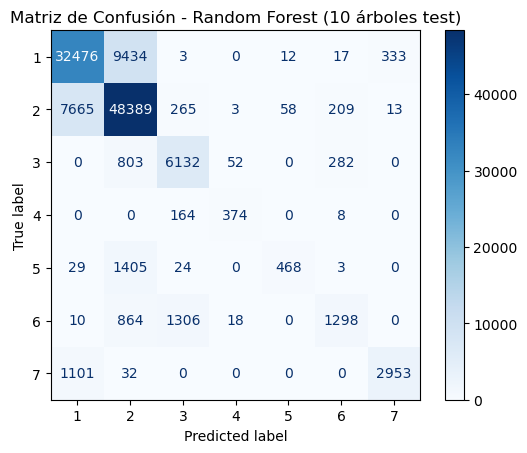

Total de ejemplos: 116203
Ejemplos correctamente clasificados: 92090
Ejemplos incorrectamente clasificados: 24113
Precisión general: 0.7925


In [30]:
# Matriz de confusión
conf_matrix_test_10 = confusion_matrix(y_test, y_pred_test_10)

# Visualización
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_test_10, display_labels=randomForest_10.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matriz de Confusión - Random Forest (10 árboles test)")
plt.show()


# Sumar la diagonal principal (predicciones correctas)
correct_predictions_test_10 = conf_matrix_test_10.diagonal().sum()

# Mostrar el total de ejemplos y los correctos
total_predictions_test_10 = conf_matrix_test_10.sum()
incorrect_predictions_test_10=total_predictions_test_10-correct_predictions_test_10
print(f"Total de ejemplos: {total_predictions_test_10}")
print(f"Ejemplos correctamente clasificados: {correct_predictions_test_10}")
print(f"Ejemplos incorrectamente clasificados: {incorrect_predictions_test_10}")
print(f"Precisión general: {correct_predictions_test_10 / total_predictions_test_10:.4f}")

Visualiza los valores de precision, recall, f1 para cada una de las clases. 
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

In [ ]:
print(classification_report(y_test, y_pred_test_10))

"""
Como pasaba anteriormente en el train, ocurre lo mismo en el test.

Sí funciona mejor para unas clases que para otras. En general la precisión es alta en todas.

Pero sorprende ver como el recall es bajo para el 6, pero especialmente para el 5, esto implica que tenemos muchos falsos negativos para estas dos variables.

Si echamos un ojo a la matriz de confusión, vemos que hay muchas instancias (muchísimas de ahí el recall tan bajo) que eran realmente 5 y se han etiquetado como 2.
También había muchas que eran 6 y se han etiquetado como 2 y como 3. Estos son los mayores problemas que hay en el modelo. No lo podemos considerar un buen modelo para predecir varias de las clases.
"""

              precision    recall  f1-score   support

           1       0.79      0.77      0.78     42275
           2       0.79      0.85      0.82     56602
           3       0.78      0.84      0.81      7269
           4       0.84      0.68      0.75       546
           5       0.87      0.24      0.38      1929
           6       0.71      0.37      0.49      3496
           7       0.90      0.72      0.80      4086

    accuracy                           0.79    116203
   macro avg       0.81      0.64      0.69    116203
weighted avg       0.79      0.79      0.79    116203



'\nComo pasaba anteriormente en el train, ocurre lo mismo en el test.\n\nSí funciona mejor para unas clases que para otras. En general la precisión es alta en todas.\n\nPero sorprende ver como el recall es bajo para el 6, pero especialmente para el 5, esto implica que tenemos muchos falsos negativos para estas dos variables.\n\nSi echamos un ojo a la matriz de confusión, vemos que hay muchas instancias (muchísimas de ahí el recall tan bajo) que eran realmente 5 y se han etiquetado como 2.\nTambién había muchas que eran 6 y se han etiquetado como 2 y como 3. Estos son los mayores problemas que hay en el modelo. No lo podemos considerar un buen modelo para predecir varias de las clases.\n'

In [32]:
# Vamos a hacer prueba con el class_weight
randomForest_10_cw = RandomForestClassifier(n_estimators = 10, class_weight='balanced',criterion= particion,
                                       max_depth = max_depth, min_samples_split = min_samples_split,
                                      min_samples_leaf = min_samples_leaf, max_features =None)

#20 árboles class weight
# Entrenamiento
randomForest_10_cw.fit(X_train, y_train)
    
# Predicción en el conjunto de prueba
y_pred_train_10_cw = randomForest_10_cw.predict(X_train)
    
# Evaluación
accuracy_10_cw = accuracy_score(y_train, y_pred_train_10_cw)
print(f"Accuracy con 10 árboles y class weight: {accuracy_10_cw:.4f}")
print(classification_report(y_train, y_pred_train_10_cw))

Accuracy con 10 árboles y class weight: 0.6811
              precision    recall  f1-score   support

           1       0.75      0.72      0.74    169565
           2       0.82      0.60      0.70    226699
           3       0.81      0.76      0.79     28485
           4       0.66      0.97      0.78      2201
           5       0.14      0.94      0.24      7564
           6       0.45      0.84      0.59     13871
           7       0.53      0.95      0.68     16424

    accuracy                           0.68    464809
   macro avg       0.59      0.83      0.64    464809
weighted avg       0.76      0.68      0.71    464809



Vemos que sigue sin ser un buen modelo. Habría que probar tocando diferentes parametros, para ver si obtenemos alguno que nos pueda valer.

**Support Vector Machine**

In [33]:
# Importamos las librerías para utilizar las máquinas de vector de soportes.
# Utilizaremos la librería svm:

from sklearn import svm

#Cargamos también las librerías para hacer la matriz de confusión y la cross validation:

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold

Para la implementación del modelo de clasificación de SVM usaremos la clase Support Vector Classifier de sklearn, https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

El algoritmo de SVM necesita ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- C
- kernel
- degree
- gamma

Indica qué son cada uno de estos hiperparámetros

- C:
Es el parametro de regularización (es la función de coste). Controla la tolerancia del modelo a errores de clasificación en el conjunto de entrenamiento.
Cuanto mayor es C, menor es el margen, y cuanto menor es C, mayor es el margen.

- kernel:
Especifica la función del núcleo (kernel) que transforma los datos para que el modelo pueda encontrar un límite de decisión óptimo en espacios de mayor dimensión.

- degree:
Especifica el grado del polinomio para el núcleo polinómico.

- gamma:
Controla la influencia de una sola instancia de entrenamiento. Especificamente define el alcance de la influencia de cada ejemplo en el límite de decisión.
Marca el comportamiento del kernel, cuanto más pequeño es el valor más se parece a un kernel lineal. Cuanto mayor es el modelo mayor la flexibilidad.


Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro decision_function_shape

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

Este parámetro controla cómo el modelo SVM calcula y estructura las salidas para problemas multiclase.

- Valores disponibles:

1. 'ovr'

Para un problema con K clases, se entrena un modelo SVM binario para cada clase, considerando esa clase como la "positiva" y todas las demás como negativas.

2. 'ovo'

Entrena un modelo binario para cada par de clases. Este enfoque puede ser más preciso pero computacionalmente más costoso.

Tenemos un dataset de más de medio millón de instancias, y para el objetivo de la actividad no hacen falta tantas. Por eso, antes de aplicar SVM vamos a reducir el número de instancias. SVM requiere una gran carga computacional y con ese volumen de instancias el tiempo requerido sería demasiado elevado.

In [34]:
df_SVM = df.head(100000)

#Realice el ejercicio sin balancear, obteniendo buenos resultados Voy a realizar un balance y comparar los dos

In [35]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

df_balanceado=df

# Separamos los datos en los conjuntos de entrenamiento y test.
X_svm_bal, y_svm_bal = df_balanceado.drop('Cover_Type',axis=1),df['Cover_Type']

# Crear el submuestreador
under_sampler = RandomUnderSampler(sampling_strategy={
    cls: min(count, 14286) for cls, count in y_svm_bal.value_counts().items()
}, random_state=42)

# Aplicar submuestreo
X_under, y_under = under_sampler.fit_resample(X_svm_bal, y_svm_bal)


# Sobremuestreo para las clases con menos de 14,286 datos
over_sampler = RandomOverSampler(sampling_strategy={
    cls: max(count, 14285) for cls, count in y_under.value_counts().items()
}, random_state=42)

X_balanced, y_balanced = over_sampler.fit_resample(X_under, y_under)


# Reconstruir el DataFrame balanceado
df_SVM_balanceado = pd.concat([pd.DataFrame(X_balanced, columns=X_svm_bal.columns), pd.Series(y_balanced, name='Cover_Type')], axis=1)


# Mostrar las distribuciones de clases
print(df_SVM_balanceado['Cover_Type'].value_counts().sort_index())

Cover_Type
1    14286
2    14286
3    14286
4    14285
5    14285
6    14286
7    14286
Name: count, dtype: int64


In [36]:
"""
Voy a hacer una tercera prueba sin sobremuestrear
Me quedará:
1 17599
2 17598
3 17598
4 2747
5 9493
6 17367
7 17598
"""


df_ubalanceado=df

# Separamos los datos en los conjuntos de entrenamiento y test.
X_svm_ubal, y_svm_ubal = df_ubalanceado.drop('Cover_Type',axis=1),df['Cover_Type']

# Crear el submuestreador
sampling_strategy = {1: 17599, 2: 17598, 3: 17598, 4: 2747, 5: 9493, 6: 17367, 7: 17598}
uunder_sampler = RandomUnderSampler(sampling_strategy=sampling_strategy
, random_state=42)

# Aplicar submuestreo
X_ubalanced, y_ubalanced = uunder_sampler.fit_resample(X_svm_ubal, y_svm_ubal)

# Reconstruir el DataFrame balanceado
df_SVM_ubalanceado = pd.concat([pd.DataFrame(X_ubalanced, columns=X_svm_ubal.columns), pd.Series(y_ubalanced, name='Cover_Type')], axis=1)


# Mostrar las distribuciones de clases
print(df_SVM_ubalanceado['Cover_Type'].value_counts().sort_index())

Cover_Type
1    17599
2    17598
3    17598
4     2747
5     9493
6    17367
7    17598
Name: count, dtype: int64


In [37]:
"""
Voy a hacer una última prueba sin sobremuestrear y con un balanceado perfecto
Me quedará:
1 2747
2 2747
3 2747
4 2747
5 2747
6 2747
7 2747
"""


df_usbalanceado=df

# Separamos los datos en los conjuntos de entrenamiento y test.
X_svm_usbal, y_svm_usbal = df_usbalanceado.drop('Cover_Type',axis=1),df['Cover_Type']

# Crear el submuestreador
sampling_strategy = {1: 2747, 2: 2747, 3: 2747, 4: 2747, 5: 2747, 6: 2747, 7: 2747}
usunder_sampler = RandomUnderSampler(sampling_strategy=sampling_strategy
, random_state=42)

# Aplicar submuestreo
X_usbalanced, y_usbalanced = usunder_sampler.fit_resample(X_svm_usbal, y_svm_usbal)

# Reconstruir el DataFrame balanceado
df_SVM_usbalanceado = pd.concat([pd.DataFrame(X_usbalanced, columns=X_svm_usbal.columns), pd.Series(y_usbalanced, name='Cover_Type')], axis=1)


# Mostrar las distribuciones de clases
print(df_SVM_usbalanceado['Cover_Type'].value_counts().sort_index())

Cover_Type
1    2747
2    2747
3    2747
4    2747
5    2747
6    2747
7    2747
Name: count, dtype: int64


Nota: recuerda revisar que esta manera de seleccionar un subconjunto de instancias no altera la clase objetivo. Deberías tener un porcentaje similar de instancias de cada clase. Si no fuera así, deberás cambiar la manera de seleccionar el subconjunto.

Aunque no haría falta, vamos a comprobar como funciona el SVM para los cuatro casos anteriores. Así veremos: como afecta que no esté balanceadopara los primeros 100000 datos y para los que hemos seleccionado, como afecta que copiemos datos y como afecta una muestra menor, que una vez vistos los resultados me parece la mejor opción de las planteadas para este caso en particular.

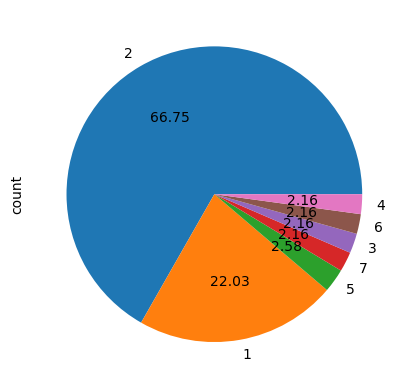

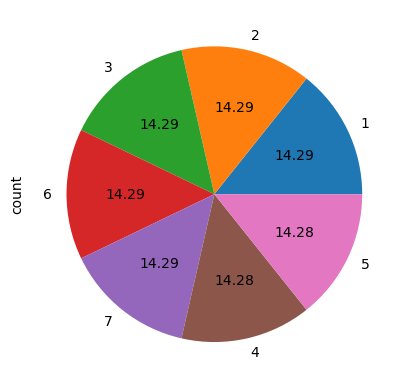

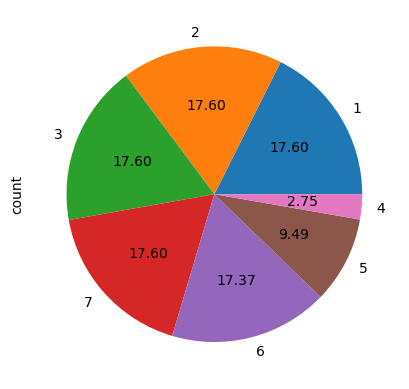

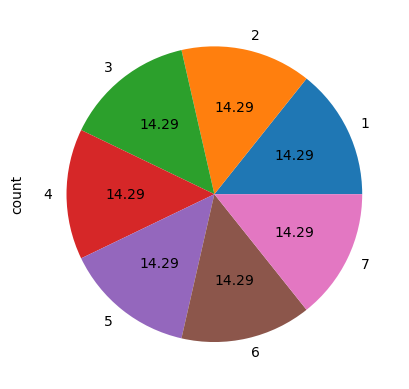

In [38]:
df_SVM['Cover_Type'].value_counts().plot(kind='pie',autopct='%.2f',)
plt.show()

df_SVM_balanceado['Cover_Type'].value_counts().plot(kind='pie',autopct='%.2f',)
plt.show()

df_SVM_ubalanceado['Cover_Type'].value_counts().plot(kind='pie',autopct='%.2f',)
plt.show()

df_SVM_usbalanceado['Cover_Type'].value_counts().plot(kind='pie',autopct='%.2f',)
plt.show()

In [39]:

# Con el nuevo número de instancias, separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

#Con datos desbalanceados
X_svm, y_svm = df_SVM.drop('Cover_Type',axis=1),df_SVM['Cover_Type']

X_train_svm,X_test_svm,y_train_svm,y_test_svm = train_test_split(X_svm, y_svm, test_size=0.2, random_state=1)

#Con datos balanceados undersampling y oversamplig
X_svm_balanceado, y_svm_balanceado = df_SVM_balanceado.drop('Cover_Type',axis=1),df_SVM_balanceado['Cover_Type']

X_train_svm_balanceado,X_test_svm_balanceado,y_train_svm_balanceado,y_test_svm_balanceado = train_test_split(X_svm_balanceado, y_svm_balanceado, test_size=0.2, random_state=1)

#Con datos balanceados undersampling 100000
X_svm_ubalanceado, y_svm_ubalanceado = df_SVM_ubalanceado.drop('Cover_Type',axis=1),df_SVM_ubalanceado['Cover_Type']

X_train_svm_ubalanceado,X_test_svm_ubalanceado,y_train_svm_ubalanceado,y_test_svm_ubalanceado = train_test_split(X_svm_ubalanceado, y_svm_ubalanceado, test_size=0.2, random_state=1)

#Con datos balanceados perfectos undersampling a la menor clase
X_svm_usbalanceado, y_svm_usbalanceado = df_SVM_usbalanceado.drop('Cover_Type',axis=1),df_SVM_usbalanceado['Cover_Type']

X_train_svm_usbalanceado,X_test_svm_usbalanceado,y_train_svm_usbalanceado,y_test_svm_usbalanceado = train_test_split(X_svm_usbalanceado, y_svm_usbalanceado, test_size=0.2, random_state=1)

Como primer paso para crear un clasificador de SVM hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos. ¿Hace falta normalizar los datos?

Sí es necesario normalizar los datos antes de entrenar un clasificador SVM en la mayoría de los casos. Esto es porque, a diferencia del Random Forest, SVM no es invariante a la escala de las características, y la escala de los datos puede afectar significativamente al modelo.

Sin embargo, esta normalización no es necesaria en one hot encoding, porque ya están normalizadas.

In [ ]:
#Estandarizaremos con StandardScaler
from sklearn.preprocessing import StandardScaler
from pandas import DataFrame

categorical_columns = [col for col in df_SVM.columns if col.startswith("Wilderness_Area") or col.startswith("Soil_Type")]

#Con datos desbalanceados
X_train_svm_categorical = X_train_svm[categorical_columns]
X_train_svm_others = X_train_svm.drop(columns=categorical_columns)

X_test_svm_categorical = X_test_svm[categorical_columns]
X_test_svm_others = X_test_svm.drop(columns=categorical_columns)

scaler = StandardScaler()

# Para no escalar el índice
index_train = X_train_svm_others.index  # Guarda el índice antes de escalar
index_test =X_test_svm_others.index # Guarda el índice antes de escalar

X_train_svm_others_scaled = scaler.fit_transform(X_train_svm_others)
X_test_svm_others_scaled = scaler.fit_transform(X_test_svm_others)

X_train_svm_others_scaled = pd.DataFrame(X_train_svm_others_scaled, index=index_train, columns=X_train_svm_others.columns)
X_test_svm_others_scaled = pd.DataFrame(X_test_svm_others_scaled, index=index_test, columns=X_test_svm_others.columns)


#Con datos balanceados con under y over
X_train_svm_categorical_balanceado = X_train_svm_balanceado[categorical_columns]
X_train_svm_others_balanceado = X_train_svm_balanceado.drop(columns=categorical_columns)

X_test_svm_categorical_balanceado = X_test_svm_balanceado[categorical_columns]
X_test_svm_others_balanceado = X_test_svm_balanceado.drop(columns=categorical_columns)

# Para no escalar el índice
index_train = X_train_svm_others_balanceado.index  # Guarda el índice antes de escalar
index_test =X_test_svm_others_balanceado.index # Guarda el índice antes de escalar

X_train_svm_others_scaled_balanceado = scaler.fit_transform(X_train_svm_others_balanceado)
X_test_svm_others_scaled_balanceado = scaler.fit_transform(X_test_svm_others_balanceado)

X_train_svm_others_scaled_balanceado = pd.DataFrame(X_train_svm_others_scaled_balanceado, index=index_train, columns=X_train_svm_others_balanceado.columns)
X_test_svm_others_scaled_balanceado = pd.DataFrame(X_test_svm_others_scaled_balanceado, index=index_test, columns=X_test_svm_others_balanceado.columns)



#Con datos balanceados con undersampling (100000 muestras) 
X_train_svm_categorical_ubalanceado = X_train_svm_ubalanceado[categorical_columns]
X_train_svm_others_ubalanceado = X_train_svm_ubalanceado.drop(columns=categorical_columns)

X_test_svm_categorical_ubalanceado = X_test_svm_ubalanceado[categorical_columns]
X_test_svm_others_ubalanceado = X_test_svm_ubalanceado.drop(columns=categorical_columns)

# Para no escalar el índice
index_train = X_train_svm_others_ubalanceado.index  # Guarda el índice antes de escalar
index_test =X_test_svm_others_ubalanceado.index # Guarda el índice antes de escalar

X_train_svm_others_scaled_ubalanceado = scaler.fit_transform(X_train_svm_others_ubalanceado)
X_test_svm_others_scaled_ubalanceado = scaler.fit_transform(X_test_svm_others_ubalanceado)

X_train_svm_others_scaled_ubalanceado = pd.DataFrame(X_train_svm_others_scaled_ubalanceado, index=index_train, columns=X_train_svm_others_ubalanceado.columns)
X_test_svm_others_scaled_ubalanceado = pd.DataFrame(X_test_svm_others_scaled_ubalanceado, index=index_test, columns=X_test_svm_others_ubalanceado.columns)



#Con datos balanceados con undersampling (19229 muestras) 
X_train_svm_categorical_usbalanceado = X_train_svm_usbalanceado[categorical_columns]
X_train_svm_others_usbalanceado = X_train_svm_usbalanceado.drop(columns=categorical_columns)

X_test_svm_categorical_usbalanceado = X_test_svm_usbalanceado[categorical_columns]
X_test_svm_others_usbalanceado = X_test_svm_usbalanceado.drop(columns=categorical_columns)

# Para no escalar el índice
index_train = X_train_svm_others_usbalanceado.index  # Guarda el índice antes de escalar
index_test =X_test_svm_others_usbalanceado.index # Guarda el índice antes de escalar

X_train_svm_others_scaled_usbalanceado = scaler.fit_transform(X_train_svm_others_usbalanceado)
X_test_svm_others_scaled_usbalanceado = scaler.fit_transform(X_test_svm_others_usbalanceado)

X_train_svm_others_scaled_usbalanceado = pd.DataFrame(X_train_svm_others_scaled_usbalanceado, index=index_train, columns=X_train_svm_others_usbalanceado.columns)
X_test_svm_others_scaled_usbalanceado = pd.DataFrame(X_test_svm_others_scaled_usbalanceado, index=index_test, columns=X_test_svm_others_usbalanceado.columns)
## COMPLETAR

In [41]:
# Ahora juntamos los datos estandarizados

X_train_svm_scaled = pd.concat([X_train_svm_others_scaled, X_train_svm_categorical], axis=1)
X_test_svm_scaled = pd.concat([X_test_svm_others_scaled, X_test_svm_categorical], axis=1)

X_train_svm_scaled_balanceado = pd.concat([X_train_svm_others_scaled_balanceado, X_train_svm_categorical_balanceado], axis=1)
X_test_svm_scaled_balanceado = pd.concat([X_test_svm_others_scaled_balanceado, X_test_svm_categorical_balanceado], axis=1)

X_train_svm_scaled_ubalanceado = pd.concat([X_train_svm_others_scaled_ubalanceado, X_train_svm_categorical_ubalanceado], axis=1)
X_test_svm_scaled_ubalanceado = pd.concat([X_test_svm_others_scaled_ubalanceado, X_test_svm_categorical_ubalanceado], axis=1)

X_train_svm_scaled_usbalanceado = pd.concat([X_train_svm_others_scaled_usbalanceado, X_train_svm_categorical_usbalanceado], axis=1)
X_test_svm_scaled_usbalanceado = pd.concat([X_test_svm_others_scaled_usbalanceado, X_test_svm_categorical_usbalanceado], axis=1)

Entrena un conjunto de modelos de SVM que utilicen todas las variables del dataset, con C = 0.1 hasta 1000 con cinco valores diferentes; kernel radial, y gamma con valor scale.

In [42]:
from sklearn.svm import SVC

C = {0.1, 1, 10, 100, 1000}
kernel = 'rbf'
gamma = 'scale'

"""
svc = [SVC(C=i, kernel=kernel, gamma=gamma) for i in C]
svc
"""

'\nsvc = [SVC(C=i, kernel=kernel, gamma=gamma) for i in C]\nsvc\n'

##### Modelo desbalanceado

In [43]:
model_0_1 = svm.SVC(C=0.1, kernel=kernel, gamma=gamma)
model_0_1.fit(X_train_svm_scaled, y_train_svm)



SVC(C=0.1)

In [44]:
model_1 = svm.SVC(C=1, kernel=kernel, gamma=gamma)
model_1.fit(X_train_svm_scaled, y_train_svm)

SVC(C=1)

In [45]:
model_10 = svm.SVC(C=10, kernel=kernel, gamma=gamma)
model_10.fit(X_train_svm_scaled, y_train_svm)

SVC(C=10)

In [46]:
model_100 = svm.SVC(C=100, kernel=kernel, gamma=gamma)
model_100.fit(X_train_svm_scaled, y_train_svm)

SVC(C=100)

In [47]:
model_1000 = svm.SVC(C=1000, kernel=kernel, gamma=gamma)
model_1000.fit(X_train_svm_scaled, y_train_svm)

SVC(C=1000)

##### Modelo balanceado con undersampling y oversampling

In [ ]:
model_0_1_balanceado = svm.SVC(C=0.1, kernel=kernel, gamma=gamma)
model_0_1_balanceado.fit(X_train_svm_scaled_balanceado, y_train_svm_balanceado)

SVC(C=0.1)

In [49]:
model_1_balanceado = svm.SVC(C=1, kernel=kernel, gamma=gamma)
model_1_balanceado.fit(X_train_svm_scaled_balanceado, y_train_svm_balanceado)

SVC(C=1)

In [50]:
model_10_balanceado = svm.SVC(C=10, kernel=kernel, gamma=gamma)
model_10_balanceado.fit(X_train_svm_scaled_balanceado, y_train_svm_balanceado)

SVC(C=10)

In [51]:
model_100_balanceado = svm.SVC(C=100, kernel=kernel, gamma=gamma)
model_100_balanceado.fit(X_train_svm_scaled_balanceado, y_train_svm_balanceado)

SVC(C=100)

In [52]:
model_1000_balanceado = svm.SVC(C=1000, kernel=kernel, gamma=gamma)
model_1000_balanceado.fit(X_train_svm_scaled_balanceado, y_train_svm_balanceado)

SVC(C=1000)

##### Modelo balanceado con undersampling (100000 muestras)

In [53]:
model_0_1_ubalanceado = svm.SVC(C=0.1, kernel=kernel, gamma=gamma)
model_0_1_ubalanceado.fit(X_train_svm_scaled_ubalanceado, y_train_svm_ubalanceado)

SVC(C=0.1)

In [54]:
model_1_ubalanceado = svm.SVC(C=1, kernel=kernel, gamma=gamma)
model_1_ubalanceado.fit(X_train_svm_scaled_ubalanceado, y_train_svm_ubalanceado)

SVC(C=1)

In [55]:
model_10_ubalanceado = svm.SVC(C=10, kernel=kernel, gamma=gamma)
model_10_ubalanceado.fit(X_train_svm_scaled_ubalanceado, y_train_svm_ubalanceado)

SVC(C=10)

In [56]:
model_100_ubalanceado = svm.SVC(C=100, kernel=kernel, gamma=gamma)
model_100_ubalanceado.fit(X_train_svm_scaled_ubalanceado, y_train_svm_ubalanceado)

SVC(C=100)

In [57]:
model_1000_ubalanceado = svm.SVC(C=1000, kernel=kernel, gamma=gamma)
model_1000_ubalanceado.fit(X_train_svm_scaled_ubalanceado, y_train_svm_ubalanceado)

SVC(C=1000)

##### Modelo balanceado con undersampling (19229 muestras)

In [58]:
model_0_1_usbalanceado = svm.SVC(C=0.1, kernel=kernel, gamma=gamma)
model_0_1_usbalanceado.fit(X_train_svm_scaled_usbalanceado, y_train_svm_usbalanceado)

SVC(C=0.1)

In [59]:
model_1_usbalanceado = svm.SVC(C=1, kernel=kernel, gamma=gamma)
model_1_usbalanceado.fit(X_train_svm_scaled_usbalanceado, y_train_svm_usbalanceado)

SVC(C=1)

In [60]:

model_10_usbalanceado = svm.SVC(C=10, kernel=kernel, gamma=gamma)
model_10_usbalanceado.fit(X_train_svm_scaled_usbalanceado, y_train_svm_usbalanceado)

SVC(C=10)

In [61]:
model_100_usbalanceado = svm.SVC(C=100, kernel=kernel, gamma=gamma)
model_100_usbalanceado.fit(X_train_svm_scaled_usbalanceado, y_train_svm_usbalanceado)

SVC(C=100)

In [62]:
model_1000_usbalanceado = svm.SVC(C=1000, kernel=kernel, gamma=gamma)
model_1000_usbalanceado.fit(X_train_svm_scaled_usbalanceado, y_train_svm_usbalanceado)

SVC(C=1000)

Después de hacer el entrenamiento, visualiza las matrices de confusión de los modelos entrenados.

In [ ]:
# Realizamos las predicciones para el modelo desbalanceado
y_pred_train_0_1 = model_0_1.predict(X_train_svm_scaled)
y_pred_train_1 = model_1.predict(X_train_svm_scaled)
y_pred_train_10 = model_10.predict(X_train_svm_scaled)
y_pred_train_100 = model_100.predict(X_train_svm_scaled)
y_pred_train_1000 = model_1000.predict(X_train_svm_scaled)
  


In [65]:
# Realizamos las predicciones para el modelo balanceado con undersampling y oversampling
y_pred_train_0_1_balanceado = model_0_1_balanceado.predict(X_train_svm_scaled_balanceado)
y_pred_train_1_balanceado = model_1_balanceado.predict(X_train_svm_scaled_balanceado)
y_pred_train_10_balanceado = model_10_balanceado.predict(X_train_svm_scaled_balanceado)
y_pred_train_100_balanceado = model_100_balanceado.predict(X_train_svm_scaled_balanceado)
y_pred_train_1000_balanceado = model_1000_balanceado.predict(X_train_svm_scaled_balanceado)

In [66]:
# Realizamos las predicciones para el modelo balanceado
y_pred_train_0_1_ubalanceado = model_0_1_ubalanceado.predict(X_train_svm_scaled_ubalanceado)
y_pred_train_1_ubalanceado = model_1_ubalanceado.predict(X_train_svm_scaled_ubalanceado)
y_pred_train_10_ubalanceado = model_10_ubalanceado.predict(X_train_svm_scaled_ubalanceado)
y_pred_train_100_ubalanceado = model_100_ubalanceado.predict(X_train_svm_scaled_ubalanceado)
y_pred_train_1000_ubalanceado = model_1000_ubalanceado.predict(X_train_svm_scaled_ubalanceado)

In [67]:
# Realizamos las predicciones para el modelo balanceado con undersampling (19229 muestras)
y_pred_train_0_1_usbalanceado = model_0_1_balanceado.predict(X_train_svm_scaled_usbalanceado)
y_pred_train_1_usbalanceado = model_1_balanceado.predict(X_train_svm_scaled_usbalanceado)
y_pred_train_10_usbalanceado = model_10_balanceado.predict(X_train_svm_scaled_usbalanceado)
y_pred_train_100_usbalanceado = model_100_balanceado.predict(X_train_svm_scaled_usbalanceado)
y_pred_train_1000_usbalanceado = model_1000_balanceado.predict(X_train_svm_scaled_usbalanceado)

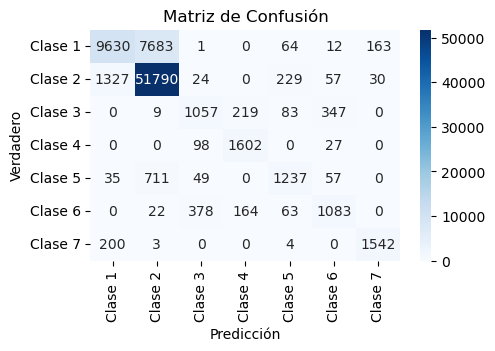

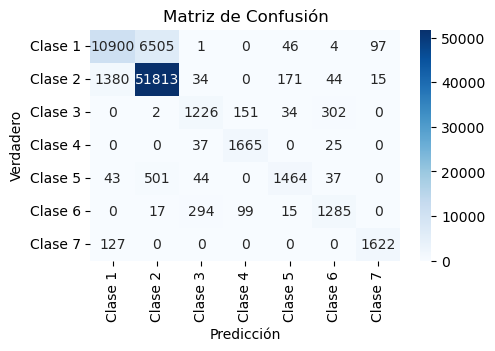

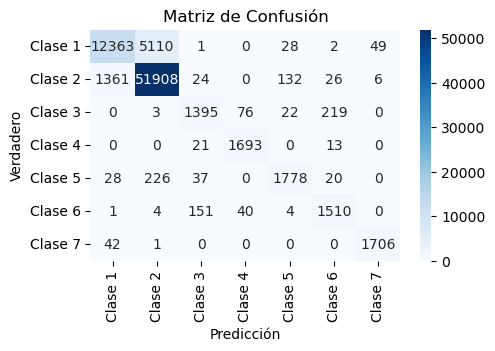

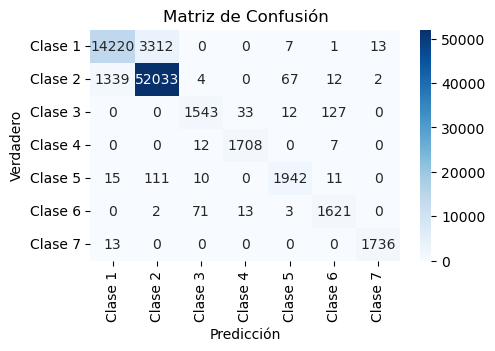

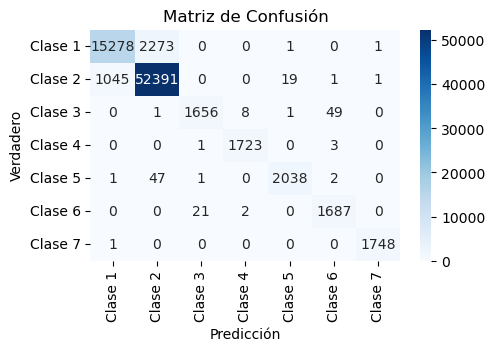

In [68]:
# Datos desbalanceados
# Calculamos la matriz de confusión
cm_0_1 = confusion_matrix(y_train_svm, y_pred_train_0_1)
cm_1 = confusion_matrix(y_train_svm, y_pred_train_1)
cm_10 = confusion_matrix(y_train_svm, y_pred_train_10)
cm_100 = confusion_matrix(y_train_svm, y_pred_train_100)
cm_1000 = confusion_matrix(y_train_svm, y_pred_train_1000) 
    
# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_0_1, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_10, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_100, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_1000, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

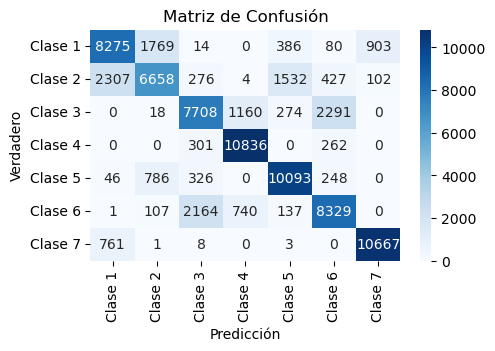

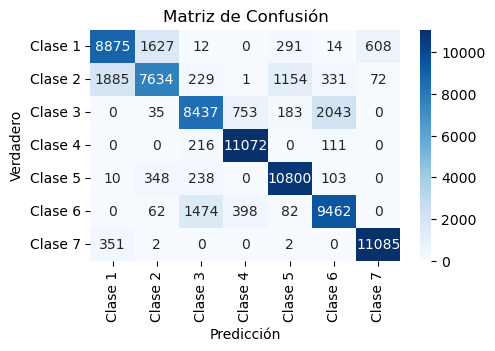

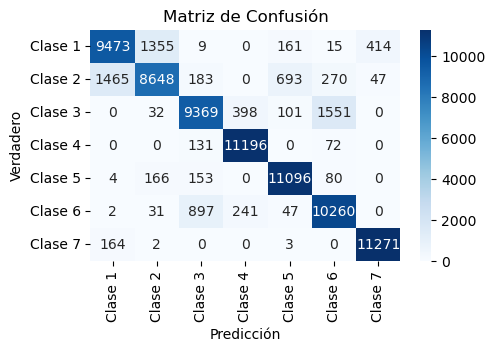

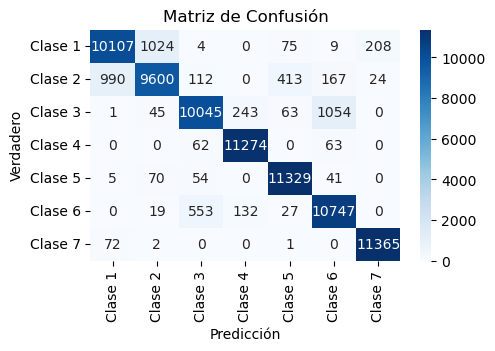

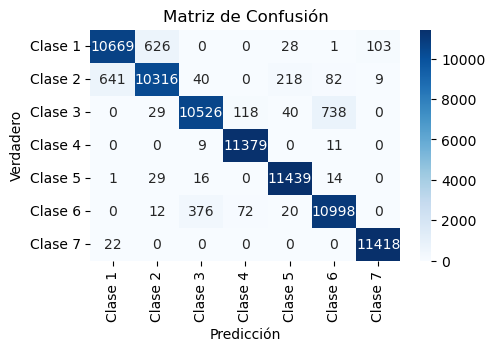

In [69]:
# Datos balanceados con undersample y oversample
# Calculamos la matriz de confusión
cm_0_1_balanceado = confusion_matrix(y_train_svm_balanceado, y_pred_train_0_1_balanceado)
cm_1_balanceado = confusion_matrix(y_train_svm_balanceado, y_pred_train_1_balanceado)
cm_10_balanceado = confusion_matrix(y_train_svm_balanceado, y_pred_train_10_balanceado)
cm_100_balanceado = confusion_matrix(y_train_svm_balanceado, y_pred_train_100_balanceado)
cm_1000_balanceado = confusion_matrix(y_train_svm_balanceado, y_pred_train_1000_balanceado) 
    
# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_0_1_balanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_1_balanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_10_balanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_100_balanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_1000_balanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

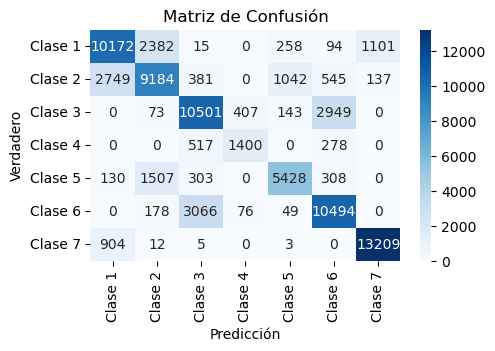

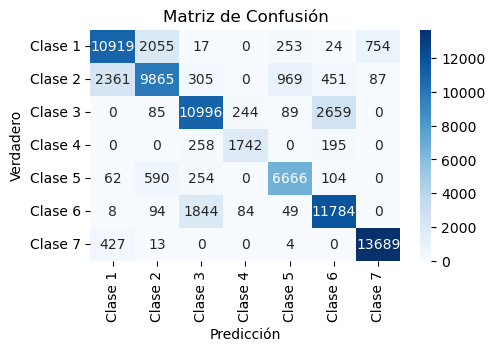

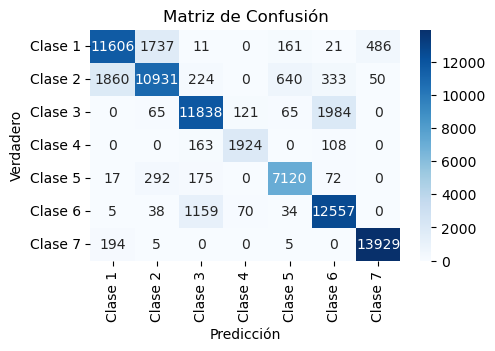

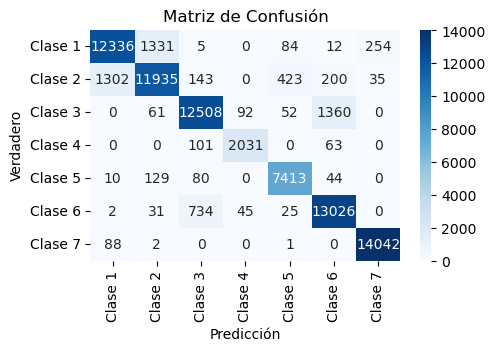

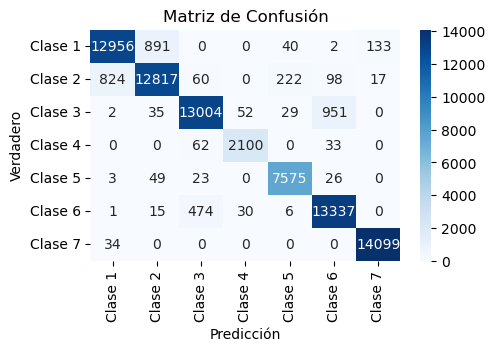

In [70]:
# Datos balanceados con undersample (100000 muestras)
# Calculamos la matriz de confusión
cm_0_1_ubalanceado = confusion_matrix(y_train_svm_ubalanceado, y_pred_train_0_1_ubalanceado)
cm_1_ubalanceado = confusion_matrix(y_train_svm_ubalanceado, y_pred_train_1_ubalanceado)
cm_10_ubalanceado = confusion_matrix(y_train_svm_ubalanceado, y_pred_train_10_ubalanceado)
cm_100_ubalanceado = confusion_matrix(y_train_svm_ubalanceado, y_pred_train_100_ubalanceado)
cm_1000_ubalanceado = confusion_matrix(y_train_svm_ubalanceado, y_pred_train_1000_ubalanceado) 
    
# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_0_1_ubalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_1_ubalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_10_ubalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_100_ubalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_1000_ubalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

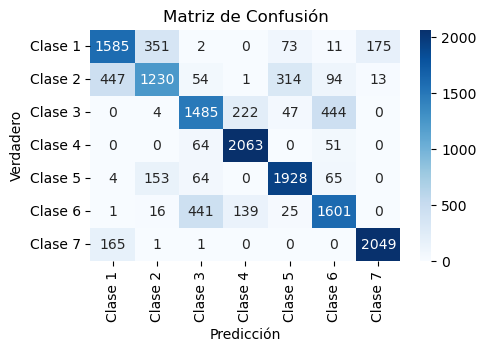

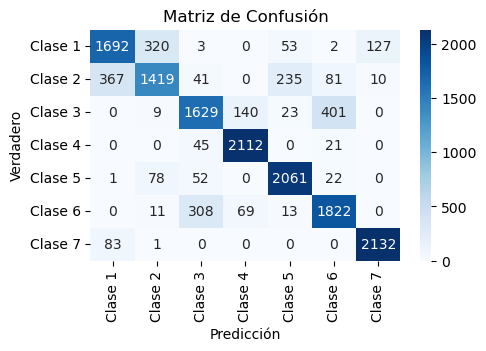

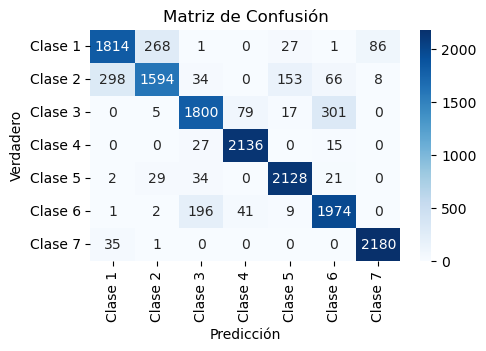

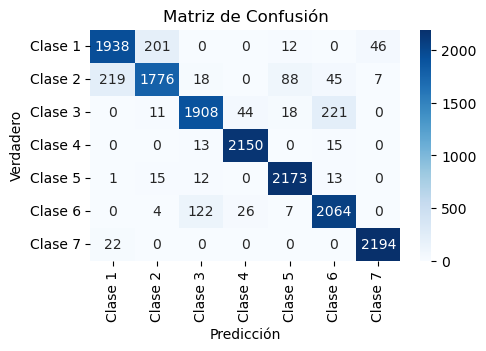

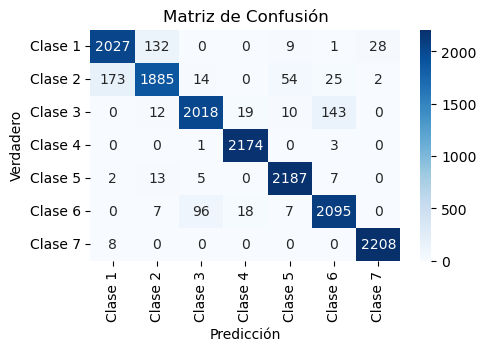

In [71]:
# Datos balanceados con undersample (19229 muestras)
# Calculamos la matriz de confusión
cm_0_1_usbalanceado = confusion_matrix(y_train_svm_usbalanceado, y_pred_train_0_1_usbalanceado)
cm_1_usbalanceado = confusion_matrix(y_train_svm_usbalanceado, y_pred_train_1_usbalanceado)
cm_10_usbalanceado = confusion_matrix(y_train_svm_usbalanceado, y_pred_train_10_usbalanceado)
cm_100_usbalanceado = confusion_matrix(y_train_svm_usbalanceado, y_pred_train_100_usbalanceado)
cm_1000_usbalanceado = confusion_matrix(y_train_svm_usbalanceado, y_pred_train_1000_usbalanceado) 
    
# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_0_1_usbalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_1_usbalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_10_usbalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_100_usbalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza la matriz de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_1000_usbalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

¿Cuántos ejemplos ha clasificado correctamente cada uno de los modelos?

In [72]:
# Ejemplos correctamente clasificados desbalanceado
correct_model_0_1 = np.trace(cm_0_1)
correct_model_1 = np.trace(cm_1)
correct_model_10 = np.trace(cm_10)
correct_model_100 = np.trace(cm_100)
correct_model_1000 = np.trace(cm_1000)

print('Modelo desbalanceado \n')
print(f"Ejemplos correctamente clasificados por el Modelo C=0.1: {correct_model_0_1}")
print(f"Ejemplos correctamente clasificados por el Modelo C=1: {correct_model_1}")
print(f"Ejemplos correctamente clasificados por el Modelo C=10: {correct_model_10}")
print(f"Ejemplos correctamente clasificados por el Modelo C=100: {correct_model_100}")
print(f"Ejemplos correctamente clasificados por el Modelo C=1000: {correct_model_1000}")


Modelo desbalanceado 

Ejemplos correctamente clasificados por el Modelo C=0.1: 67941
Ejemplos correctamente clasificados por el Modelo C=1: 69975
Ejemplos correctamente clasificados por el Modelo C=10: 72353
Ejemplos correctamente clasificados por el Modelo C=100: 74803
Ejemplos correctamente clasificados por el Modelo C=1000: 76521


In [73]:
# Ejemplos correctamente clasificados balanceado con undersampling y oversampling
correct_model_0_1_balanceado = np.trace(cm_0_1_balanceado)
correct_model_1_balanceado = np.trace(cm_1_balanceado)
correct_model_10_balanceado = np.trace(cm_10_balanceado)
correct_model_100_balanceado = np.trace(cm_100_balanceado)
correct_model_1000_balanceado = np.trace(cm_1000_balanceado)

print('Modelo balanceado con undersampling y oversampling \n')
print(f"Ejemplos correctamente clasificados por el Modelo C=0.1: {correct_model_0_1_balanceado}")
print(f"Ejemplos correctamente clasificados por el Modelo C=1: {correct_model_1_balanceado}")
print(f"Ejemplos correctamente clasificados por el Modelo C=10: {correct_model_10_balanceado}")
print(f"Ejemplos correctamente clasificados por el Modelo C=100: {correct_model_100_balanceado}")
print(f"Ejemplos correctamente clasificados por el Modelo C=1000: {correct_model_1000_balanceado}")

Modelo balanceado con undersampling y oversampling 

Ejemplos correctamente clasificados por el Modelo C=0.1: 62566
Ejemplos correctamente clasificados por el Modelo C=1: 67365
Ejemplos correctamente clasificados por el Modelo C=10: 71313
Ejemplos correctamente clasificados por el Modelo C=100: 74467
Ejemplos correctamente clasificados por el Modelo C=1000: 76745


In [74]:
# Ejemplos correctamente clasificados balanceado con undersampling (100000 muestras)
correct_model_0_1_ubalanceado = np.trace(cm_0_1_ubalanceado)
correct_model_1_ubalanceado = np.trace(cm_1_ubalanceado)
correct_model_10_ubalanceado = np.trace(cm_10_ubalanceado)
correct_model_100_ubalanceado = np.trace(cm_100_ubalanceado)
correct_model_1000_ubalanceado = np.trace(cm_1000_ubalanceado)

print('Modelo balanceado con undersampling (100000 muestras)\n')
print(f"Ejemplos correctamente clasificados por el Modelo C=0.1: {correct_model_0_1_ubalanceado}")
print(f"Ejemplos correctamente clasificados por el Modelo C=1: {correct_model_1_ubalanceado}")
print(f"Ejemplos correctamente clasificados por el Modelo C=10: {correct_model_10_ubalanceado}")
print(f"Ejemplos correctamente clasificados por el Modelo C=100: {correct_model_100_ubalanceado}")
print(f"Ejemplos correctamente clasificados por el Modelo C=1000: {correct_model_1000_ubalanceado}")

Modelo balanceado con undersampling (100000 muestras)

Ejemplos correctamente clasificados por el Modelo C=0.1: 60388
Ejemplos correctamente clasificados por el Modelo C=1: 65661
Ejemplos correctamente clasificados por el Modelo C=10: 69905
Ejemplos correctamente clasificados por el Modelo C=100: 73291
Ejemplos correctamente clasificados por el Modelo C=1000: 75888


In [75]:
# Ejemplos correctamente clasificados balanceado con undersampling (19229 muestras)
correct_model_0_1_usbalanceado = np.trace(cm_0_1_usbalanceado)
correct_model_1_usbalanceado = np.trace(cm_1_usbalanceado)
correct_model_10_usbalanceado = np.trace(cm_10_usbalanceado)
correct_model_100_usbalanceado = np.trace(cm_100_usbalanceado)
correct_model_1000_usbalanceado = np.trace(cm_1000_usbalanceado)

print('Modelo balanceado con undersampling (19229 muestras)\n')
print(f"Ejemplos correctamente clasificados por el Modelo C=0.1: {correct_model_0_1_usbalanceado}")
print(f"Ejemplos correctamente clasificados por el Modelo C=1: {correct_model_1_usbalanceado}")
print(f"Ejemplos correctamente clasificados por el Modelo C=10: {correct_model_10_usbalanceado}")
print(f"Ejemplos correctamente clasificados por el Modelo C=100: {correct_model_100_usbalanceado}")
print(f"Ejemplos correctamente clasificados por el Modelo C=1000: {correct_model_1000_usbalanceado}")

Modelo balanceado con undersampling (19229 muestras)

Ejemplos correctamente clasificados por el Modelo C=0.1: 11941
Ejemplos correctamente clasificados por el Modelo C=1: 12867
Ejemplos correctamente clasificados por el Modelo C=10: 13626
Ejemplos correctamente clasificados por el Modelo C=100: 14203
Ejemplos correctamente clasificados por el Modelo C=1000: 14594


¿Cuál de todos los modelos que has entrenado obtiene mejores resultados de precision para todas las clases? Si no hay ninguno que consideres que sea óptimo, explica cómo se comporta para cada clase el modelo que consideres que tiene mejores resultados.

In [ ]:
# Desbalanceado
report_0_1=classification_report(y_train_svm, y_pred_train_0_1)
report_1=classification_report(y_train_svm, y_pred_train_1)
report_10=classification_report(y_train_svm, y_pred_train_10)
report_100=classification_report(y_train_svm, y_pred_train_100)
report_1000=classification_report(y_train_svm, y_pred_train_1000)

print(f"Resultados modelo C=0.1: {report_0_1}")
print(f"Resultados modelo C=1: {report_1}")
print(f"Resultados modelo C=10: {report_10}")
print(f"Resultados modelo C=100: {report_100}")
print(f"Resultados modelo C=1000: {report_1000}")

Resultados modelo C=0.1:               precision    recall  f1-score   support

           1       0.86      0.55      0.67     17553
           2       0.86      0.97      0.91     53457
           3       0.66      0.62      0.64      1715
           4       0.81      0.93      0.86      1727
           5       0.74      0.59      0.66      2089
           6       0.68      0.63      0.66      1710
           7       0.89      0.88      0.89      1749

    accuracy                           0.85     80000
   macro avg       0.78      0.74      0.75     80000
weighted avg       0.85      0.85      0.84     80000

Resultados modelo C=1:               precision    recall  f1-score   support

           1       0.88      0.62      0.73     17553
           2       0.88      0.97      0.92     53457
           3       0.75      0.71      0.73      1715
           4       0.87      0.96      0.91      1727
           5       0.85      0.70      0.77      2089
           6       0.76      0

In [ ]:
# Balanceado con undersampling y oversampling
report_0_1_balanceado=classification_report(y_train_svm_balanceado, y_pred_train_0_1_balanceado)
report_1_balanceado=classification_report(y_train_svm_balanceado, y_pred_train_1_balanceado)
report_10_balanceado=classification_report(y_train_svm_balanceado, y_pred_train_10_balanceado)
report_100_balanceado=classification_report(y_train_svm_balanceado, y_pred_train_100_balanceado)
report_1000_balanceado=classification_report(y_train_svm_balanceado, y_pred_train_1000_balanceado)

print(f"Resultados modelo C=0.1: {report_0_1_balanceado}")
print(f"Resultados modelo C=1: {report_1_balanceado}")
print(f"Resultados modelo C=10: {report_10_balanceado}")
print(f"Resultados modelo C=100: {report_100_balanceado}")
print(f"Resultados modelo C=1000: {report_1000_balanceado}")

Resultados modelo C=0.1:               precision    recall  f1-score   support

           1       0.73      0.72      0.73     11427
           2       0.71      0.59      0.64     11306
           3       0.71      0.67      0.69     11451
           4       0.85      0.95      0.90     11399
           5       0.81      0.88      0.84     11499
           6       0.72      0.73      0.72     11478
           7       0.91      0.93      0.92     11440

    accuracy                           0.78     80000
   macro avg       0.78      0.78      0.78     80000
weighted avg       0.78      0.78      0.78     80000

Resultados modelo C=1:               precision    recall  f1-score   support

           1       0.80      0.78      0.79     11427
           2       0.79      0.68      0.73     11306
           3       0.80      0.74      0.77     11451
           4       0.91      0.97      0.94     11399
           5       0.86      0.94      0.90     11499
           6       0.78      0

In [78]:
# Balanceado con undersampling (100000 muesras)
report_0_1_ubalanceado=classification_report(y_train_svm_ubalanceado, y_pred_train_0_1_ubalanceado)
report_1_ubalanceado=classification_report(y_train_svm_ubalanceado, y_pred_train_1_ubalanceado)
report_10_ubalanceado=classification_report(y_train_svm_ubalanceado, y_pred_train_10_ubalanceado)
report_100_ubalanceado=classification_report(y_train_svm_ubalanceado, y_pred_train_100_ubalanceado)
report_1000_ubalanceado=classification_report(y_train_svm_ubalanceado, y_pred_train_1000_ubalanceado)

print(f"Resultados modelo C=0.1: {report_0_1_ubalanceado}")
print(f"Resultados modelo C=1: {report_1_ubalanceado}")
print(f"Resultados modelo C=10: {report_10_ubalanceado}")
print(f"Resultados modelo C=100: {report_100_ubalanceado}")
print(f"Resultados modelo C=1000: {report_1000_ubalanceado}")

Resultados modelo C=0.1:               precision    recall  f1-score   support

           1       0.73      0.73      0.73     14022
           2       0.69      0.65      0.67     14038
           3       0.71      0.75      0.73     14073
           4       0.74      0.64      0.69      2195
           5       0.78      0.71      0.74      7676
           6       0.72      0.76      0.74     13863
           7       0.91      0.93      0.92     14133

    accuracy                           0.75     80000
   macro avg       0.75      0.74      0.75     80000
weighted avg       0.75      0.75      0.75     80000

Resultados modelo C=1:               precision    recall  f1-score   support

           1       0.79      0.78      0.79     14022
           2       0.78      0.70      0.74     14038
           3       0.80      0.78      0.79     14073
           4       0.84      0.79      0.82      2195
           5       0.83      0.87      0.85      7676
           6       0.77      0

In [79]:
# Balanceado con undersampling (19229 muestras)
report_0_1_usbalanceado=classification_report(y_train_svm_usbalanceado, y_pred_train_0_1_usbalanceado)
report_1_usbalanceado=classification_report(y_train_svm_usbalanceado, y_pred_train_1_usbalanceado)
report_10_usbalanceado=classification_report(y_train_svm_usbalanceado, y_pred_train_10_usbalanceado)
report_100_usbalanceado=classification_report(y_train_svm_usbalanceado, y_pred_train_100_usbalanceado)
report_1000_usbalanceado=classification_report(y_train_svm_usbalanceado, y_pred_train_1000_usbalanceado)

print(f"Resultados modelo C=0.1: {report_0_1_usbalanceado}")
print(f"Resultados modelo C=1: {report_1_usbalanceado}")
print(f"Resultados modelo C=10: {report_10_usbalanceado}")
print(f"Resultados modelo C=100: {report_100_usbalanceado}")
print(f"Resultados modelo C=1000: {report_1000_usbalanceado}")

Resultados modelo C=0.1:               precision    recall  f1-score   support

           1       0.72      0.72      0.72      2197
           2       0.70      0.57      0.63      2153
           3       0.70      0.67      0.69      2202
           4       0.85      0.95      0.90      2178
           5       0.81      0.87      0.84      2214
           6       0.71      0.72      0.71      2223
           7       0.92      0.92      0.92      2216

    accuracy                           0.78     15383
   macro avg       0.77      0.78      0.77     15383
weighted avg       0.77      0.78      0.77     15383

Resultados modelo C=1:               precision    recall  f1-score   support

           1       0.79      0.77      0.78      2197
           2       0.77      0.66      0.71      2153
           3       0.78      0.74      0.76      2202
           4       0.91      0.97      0.94      2178
           5       0.86      0.93      0.90      2214
           6       0.78      0

Vemos que conforme aumentamos el coste, los resultados que obtenemos son cada vez mejores conforme aumentamos la función de coste (lo cual es lógico ya que a mayor coste menor margen). Hay que comprobar con los datos de test, a ver en que punto nos encontramos con overfittig.

Respecto a que modelo tiene mejores resultados. Si nos fijamos en la función de coste, vemos que todos tienen buenos resultados a partir de C=10. 
El modelo no mejora mucho a partir de C=100. 

En cuanto a los costes computacionales. Con la muestra reducida, tenemos un coste computacional mucho menor, y apenas nos afecta la función de coste.
Si afecta la función de coste para las muestras elevadas (100000 muestras), siendo muy elevados para C=1000.

No merece la pena el coste computacional extra con respecto a los que nos da de mejorar de 100 a 1000. Tarda mucho más y apenas mejoramos el modelo. Además, hay que estudiar el overfitting.

No merece la pena el coste computacional extra de pasar de 19229 muestras a 100000 muestras. Además, con 19229 muestras tenemos un balance perfecto, con todo muestras originales.

Es curioso que este modelo se comporta bien para todas las clases, en todos los modelos. No hay penalización por el desbalance entre las muestas.


Selecciona el modelo que consideras que obtiene mejores resultados y realiza las predicciones con el conjunto de datos de test.

Por todo lo que he comentado, vamos a seleccionar el modelo con las 19229 muestras.
Comparemos el conjunto de test para C=1, C=10, C=100 y C=1000.


In [ ]:
y_pred_test_1_usbalanceado = model_1_usbalanceado.predict(X_test_svm_scaled_usbalanceado)
print(y_pred_test_1_usbalanceado)
y_pred_test_10_usbalanceado = model_10_usbalanceado.predict(X_test_svm_scaled_usbalanceado)
print(y_pred_test_10_usbalanceado)
y_pred_test_100_usbalanceado = model_100_usbalanceado.predict(X_test_svm_scaled_usbalanceado)
print(y_pred_test_100_usbalanceado)
y_pred_test_1000_usbalanceado = model_1000_usbalanceado.predict(X_test_svm_scaled_usbalanceado)
print(y_pred_test_1000_usbalanceado)

[2 4 1 ... 3 5 3]
[2 4 1 ... 3 2 3]
[1 4 1 ... 3 5 6]
[1 4 1 ... 3 2 6]


Visualiza la matriz de confusión de los datos de test.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
- ¿Cuántos ejemplos ha clasificado de manera errónea?

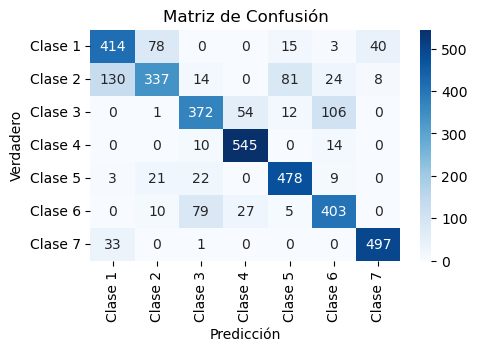

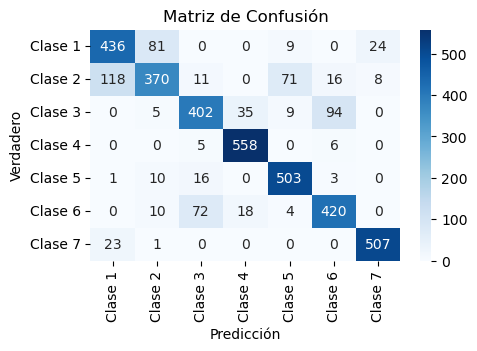

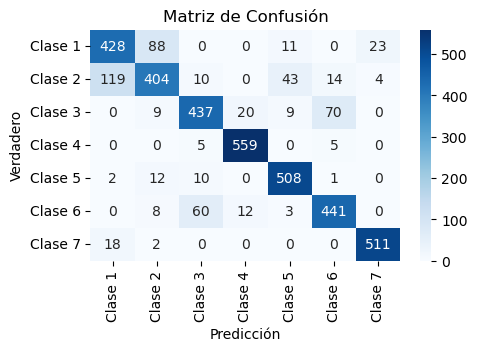

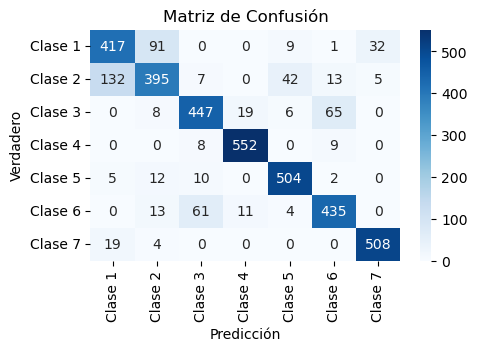

Ejemplos correctamente clasificados por el Modelo C=1 para test: 3046
Ejemplos incorrectamente clasificados por el Modelo C=1 para test: 800
Ejemplos correctamente clasificados por el Modelo C=10 para test: 3196
Ejemplos incorrectamente clasificados por el Modelo C=10 para test: 650
Ejemplos correctamente clasificados por el Modelo C=100 para test: 3288
Ejemplos incorrectamente clasificados por el Modelo C=100 para test: 558
Ejemplos correctamente clasificados por el Modelo C=1000 para test: 3258
Ejemplos incorrectamente clasificados por el Modelo C=1000 para test: 588


In [ ]:
cm_1_test_usbalanceado = confusion_matrix(y_test_svm_usbalanceado, y_pred_test_1_usbalanceado)
cm_10_test_usbalanceado = confusion_matrix(y_test_svm_usbalanceado, y_pred_test_10_usbalanceado)
cm_100_test_usbalanceado = confusion_matrix(y_test_svm_usbalanceado, y_pred_test_100_usbalanceado)
cm_1000_test_usbalanceado = confusion_matrix(y_test_svm_usbalanceado, y_pred_test_1000_usbalanceado)

# Visualiza las matrices de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_1_test_usbalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Visualiza las matrices de confusión con Seaborn
plt.figure(figsize=(5, 3))
sns.heatmap(cm_10_test_usbalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

plt.figure(figsize=(5, 3))
sns.heatmap(cm_100_test_usbalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

plt.figure(figsize=(5, 3))
sns.heatmap(cm_1000_test_usbalanceado, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Clase {i+1}' for i in range(7)], 
            yticklabels=[f'Clase {i+1}' for i in range(7)])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

correct_model_test_1_usbalanceado = np.trace(cm_1_test_usbalanceado)
total=len(y_pred_test_1_usbalanceado)
incorrect_model_test_1_usbalanceado= total-correct_model_test_1_usbalanceado
print(f"Ejemplos correctamente clasificados por el Modelo C=1 para test: {correct_model_test_1_usbalanceado}")
print(f"Ejemplos incorrectamente clasificados por el Modelo C=1 para test: {incorrect_model_test_1_usbalanceado}")

correct_model_test_10_usbalanceado = np.trace(cm_10_test_usbalanceado)
total=len(y_pred_test_10_usbalanceado)
incorrect_model_test_10_usbalanceado= total-correct_model_test_10_usbalanceado
print(f"Ejemplos correctamente clasificados por el Modelo C=10 para test: {correct_model_test_10_usbalanceado}")
print(f"Ejemplos incorrectamente clasificados por el Modelo C=10 para test: {incorrect_model_test_10_usbalanceado}")

correct_model_test_100_usbalanceado = np.trace(cm_100_test_usbalanceado)
total=len(y_pred_test_100_usbalanceado)
incorrect_model_test_100_usbalanceado= total-correct_model_test_100_usbalanceado
print(f"Ejemplos correctamente clasificados por el Modelo C=100 para test: {correct_model_test_100_usbalanceado}")
print(f"Ejemplos incorrectamente clasificados por el Modelo C=100 para test: {incorrect_model_test_100_usbalanceado}")

correct_model_test_1000_usbalanceado = np.trace(cm_1000_test_usbalanceado)
total=len(y_pred_test_1000_usbalanceado)
incorrect_model_test_1000_usbalanceado= total-correct_model_test_1000_usbalanceado
print(f"Ejemplos correctamente clasificados por el Modelo C=1000 para test: {correct_model_test_1000_usbalanceado}")
print(f"Ejemplos incorrectamente clasificados por el Modelo C=1000 para test: {incorrect_model_test_1000_usbalanceado}")

Visualiza los valores de precision, recall, f1 para cada una de las clases. 
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

In [ ]:
report_1_test_usbalanceado=classification_report(y_test_svm_usbalanceado, y_pred_test_1_usbalanceado)
print(f"Resultados modelo C=1 para test: {report_1_test_usbalanceado}")

report_10_test_usbalanceado=classification_report(y_test_svm_usbalanceado, y_pred_test_10_usbalanceado)
print(f"Resultados modelo C=10 para test: {report_10_test_usbalanceado}")

report_100_test_usbalanceado=classification_report(y_test_svm_usbalanceado, y_pred_test_100_usbalanceado)
print(f"Resultados modelo C=100 para test: {report_100_test_usbalanceado}")

report_1000_test_usbalanceado=classification_report(y_test_svm_usbalanceado, y_pred_test_1000_usbalanceado)
print(f"Resultados modelo C=1000 para test: {report_1000_test_usbalanceado}")


Resultados modelo C=1 para test:               precision    recall  f1-score   support

           1       0.71      0.75      0.73       550
           2       0.75      0.57      0.65       594
           3       0.75      0.68      0.71       545
           4       0.87      0.96      0.91       569
           5       0.81      0.90      0.85       533
           6       0.72      0.77      0.74       524
           7       0.91      0.94      0.92       531

    accuracy                           0.79      3846
   macro avg       0.79      0.79      0.79      3846
weighted avg       0.79      0.79      0.79      3846

Resultados modelo C=10 para test:               precision    recall  f1-score   support

           1       0.75      0.79      0.77       550
           2       0.78      0.62      0.69       594
           3       0.79      0.74      0.76       545
           4       0.91      0.98      0.95       569
           5       0.84      0.94      0.89       533
           

Vemos que sí predice mejor algunas clases que otras. Además, vemos que las clases que peor son las que más datos había y hemos filtrado.

También vemos que el modelo es algo peor que el de entrenamiento para los tres casos, luego hay un ligero overfitting. Apenas mejoramos las predicciones para el test aumentando la C, y sin embargo sí mejoraba mucho en el caso del entrenamiento. Cuánto más C, mayor overfitting.

Pero en general se puede considerar un modelo válido. 

Nos quedaríamos con el modelo de 19229 variables y un C=100. (Tiene más overfitting que el C=10 pero sí es ligeramente mejor). Tiene todos los valores con una precisión de más de 0.75, y teniendo el peor resultado el recall de la clase 2, con un 0.68.
Se podría ver cuál es el punto óptimo entre C=10 y C=100.

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de clasificación?

Como he comentado ya, ninguno de los modelos de Random Forest nos da una buena predicción.
Esto implica que, habría que seleccionar uno de los modelos de SVM, que sí nos dan mejores resultados.
Haciendo un análisis del tiempo que me ha tardado en correr cada uno de los modelos (se podría medir y meter en un parámetro, pero no lo veo necesario) me quedaría con el modelo de 19229 variables y con una función de coste de C=100, por todo lo explicado anteriormente.

### Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de clasificación empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

_introduce aquí la referencia APA del artículo_

Gómez-Jaramillo, P.A., González-Echavarría, F. and Pérez-Rave, J.I., Modelo de clasificación de incidentes tecnológicos desde un enfoque de aprendizaje automático
en servicios de seguros,. DYNA, 89(221), pp. 161-167, April - June, 2022.  https://doi.org/10.15446/dyna.v89n221.100070

título, autores, revista, año de publicación

- Título: 

Modelo de Clasificación de Incidentes Tecnológicos desde un Enfoque de Aprendizaje Automático en Servicios de Seguros

Technological incident classification model from a machine learning approach in insurance services

- Autores: 

Paola Andrea Gómez-Jaramillo 

Favián González-Echavarría

Jorge Iván Pérez-Rave 

- Revista de publicación:

Revista de la Facultad de Minas. Universidad Nacional de Colombia. Sede Medellín

- Año de publicación: 2022



Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la clasificación.
Técnicas de clasificación empleadas y si realiza alguna adaptación.
Principales resultados de la aplicación y de la investigación.

- Objetivo:

El objetivo de la investigación es analizar y comparar diversos métodos de aprendizaje automático para mejorar la clasificación de incidentes tecnológicos en el contexto de la suscripción de pólizas de seguros. La investigación busca determinar qué método ofrece las mejores tasas de clasificación y evaluar las implicaciones prácticas de utilizar dichos modelos en comparación con la clasificación realizada por agentes humanos, especialmente considerando la mejora en la eficiencia del proceso y la satisfacción del usuario final. Además, se pretende proporcionar guía para investigaciones futuras sobre el tema y apoyar la toma de decisiones en la optimización de la clasificación de incidentes en el sector de seguros.

- Técnicas de clasificación empleadas y si realiza alguna adaptación:

1. Árboles de clasificación.
2. SVM
3. Random Forest
4. Regresión logística
5. Análisis lineal discriminante

Adaptaciones:
Datos combinados: La investigación no solo usa características estructuradas, sino que también se incorpora el análisis de texto (descripción narrativa de los incidentes). Se realiza una comparación de rendimiento entre escenarios que incluyen solo datos estructurados, solo textos y ambos tipos de datos combinados. Esta adaptación es clave para evaluar cómo las variables de texto pueden influir en la clasificación de incidentes tecnológicos.

Evaluación comparativa con agentes humanos: Se adapta un análisis para comparar el desempeño de los modelos de clasificación con la clasificación realizada por un agente humano, con el objetivo de identificar mejoras prácticas en la eficiencia del proceso de clasificación de incidentes en el contexto de seguros.

Estas adaptaciones buscan optimizar el desempeño de la clasificación de incidentes, minimizando los errores humanos y mejorando la eficiencia del proceso, especialmente en el ámbito de seguros.

- Principales resultados de la aplicación y de la investigación: 

La investigación demuestra que Random Forest, junto con SVM y Regresión Logística, son métodos efectivos para mejorar la clasificación de incidentes en el sector de seguros, mostrando una mejora sustancial en la exactitud de clasificación respecto a los agentes humanos.

El uso de atributos de texto (descripción narrativa del incidente) contribuyó significativamente a mejorar el rendimiento de los modelos, destacando la importancia de las descripciones en el proceso de clasificación.

El ahorro de tiempo y recursos es una de las implicaciones prácticas clave, ya que los modelos de máquina reducen significativamente el tiempo de resolución de incidentes.

Este estudio proporciona una base sólida para la adopción de aprendizaje automático en la clasificación de incidentes en el sector asegurador, con implicaciones positivas tanto para la eficiencia operativa como para la satisfacción del cliente.